# Insurance Charges Prediction

## 1. Introduction

This project focuses on predicting individual medical insurance charges using demographic and lifestyle information such as age, BMI, smoking habits, number of children, sex, and geographic region. The main objective is to explore how different personal factors influence healthcare costs and to develop predictive models capable of estimating insurance expenses accurately.

The analysis begins with extensive exploratory data analysis (EDA) to identify trends, correlations, and potential relationships between variables. Several feature engineering techniques are then applied, including logarithmic transformations and interaction terms, to improve model performance and address issues such as heteroscedasticity and non-linearity.

Multiple regression and machine learning models are evaluated, including Ordinary Least Squares (OLS), LASSO, Ridge Regression, Polynomial Regression, and Random Forests. The models are compared using performance metrics such as RMSE, MAE, and R² scores, alongside cross-validation techniques to assess their generalization ability.

The dataset is imported from kaggle: https://www.kaggle.com/datasets/mirichoi0218/insurance


## 2. Importing and Preprocessing

This section focuses on loading the insurance dataset and preparing it for analysis and modeling. Basic data cleaning, verification, and preprocessing techniques are applied, including duplicate detection, datatype inspection, and transformation of categorical variables into numerical representations suitable for statistical analysis and machine learning models.

In [161]:
import kagglehub
import os

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


import statsmodels.api as sm
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### Import models
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor



We initialize a random state that will determine the stochasticity of our models and ensure reproducibility of results.

In [162]:
### Initialize a random state 
random_state = 42

We download the dataset and load it onto a pandas dataframe.

In [163]:
### Download dataset
path = kagglehub.dataset_download('mirichoi0218/insurance')

#print('Path to dataset files:', path)

### Lead file onto dataframe
df = pd.read_csv(os.path.join(path, 'insurance.csv'))

We print the first rows of the dataset to ensure the dataset has been properly loaded.

In [164]:
### Print first rows of dataframe to verify dataframe was loaded properly
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


We print basic information on the dataset.

In [165]:
### Print basic information 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


We check for duplicates in the dataset.

In [166]:
### Print number of duplicate entries
print(df.duplicated().sum())

### Print duplicate entries
df[df.duplicated()]

1


,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


Since there is only one duplicate entry we may assume that it is a genuine datapoint, and no systematic error has happened.

Next we print some basic statistics for the dataset.

In [167]:
### Print basic statistics
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## 3. Exploratory Data Analysis 

This section explores the structure and characteristics of the dataset in order to better understand the relationships between variables and insurance charges. Various visualization techniques such as histograms, scatter plots, heatmaps, violin plots, and regression plots are used to identify trends, correlations, potential outliers, and important patterns related to smoking, BMI, age, and regional differences.



We start by translating our "smoker" and "sex" variables into binary variables.

In [168]:
### Transform "sex" into a numerical binary variable
if df['sex'].isin(['male', 'female']).any():
    df['sex'] = df['sex'].map({'male': 0, 'female': 1})

### Transform "smoker" into a numerical binary variable
if df['smoker'].isin(['yes', 'no']).any():
    df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})

We count the percentage of female individuals and smoker individuals. We expect to find a balanced dataset in terms of sex.

In [169]:
### Percentage of female
pct_women = df['sex'].mean() * 100

### Percentage of smokers 
pct_smokers = df['smoker'].mean() * 100

### Print percentages
print(f"Female: {pct_women:.2f}%")
print(f"Smokers: {pct_smokers:.2f}%")

Female: 49.48%
Smokers: 20.48%


We produce the correlation matrix of our variables. Before visualizing, we must transform the "region" variable into a dummy variable. This dummy variable encoding will not facilitate visualization, so we only apply it to visualize the correlation matrix, where it is absolutely necessary.

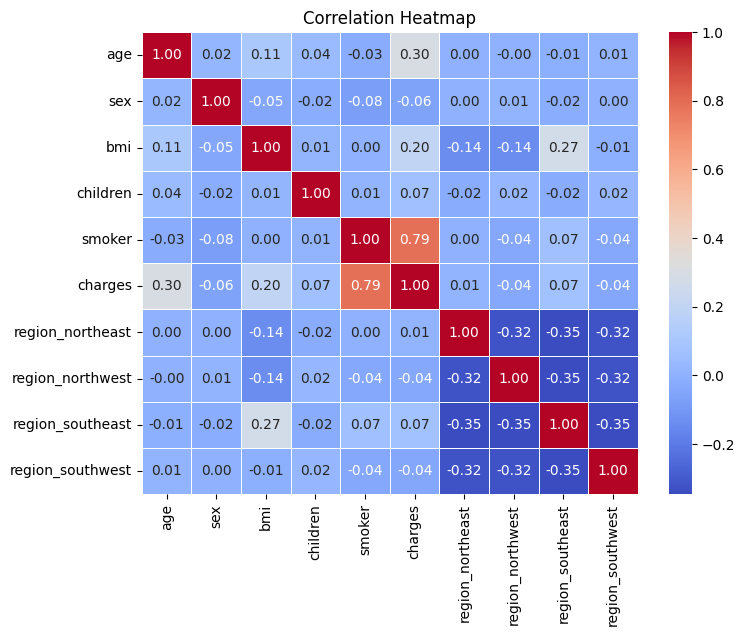

In [170]:
### Copy data  
df_corr_copy = df.copy()

### Get dummy variables for region
if 'region' in df.columns:
    df_corr_copy = pd.get_dummies(df_corr_copy, columns=['region'])

### Calculate correlation matrix
matrix = df_corr_copy.corr()

### Visualize the matrix
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

From the correlation matrix it is clear that smoker status is by far the most correlated variable to charges, our target variable. We proceed to plot the age distribution with respect to sex and smoker status respectively.

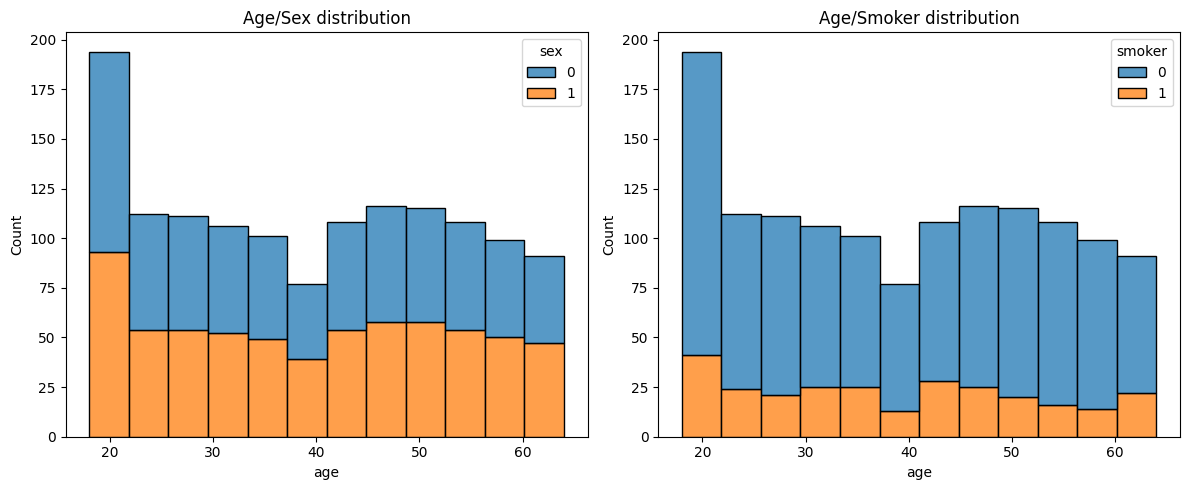

In [171]:
### Initialize axes
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

### Age distribution and sex
sns.histplot(data=df, x='age', hue='sex', multiple = 'stack', ax=axes[0])
axes[0].set_title('Age/Sex distribution')

### Age distribution and smoker status
sns.histplot(data=df, x='age', hue='smoker', multiple = 'stack', ax=axes[1])
axes[1].set_title('Age/Smoker distribution')

plt.tight_layout()
plt.show()



We notice that while the dataset is mostly balanced in terms of age, there are significantly more young individuals ( ~ 20 y.o.) than any other age. As expected, the distribution seems balanced in terms of sex, and smoker status considering the relative percentages. We additionally look at the same distribution while splitting them by region. 

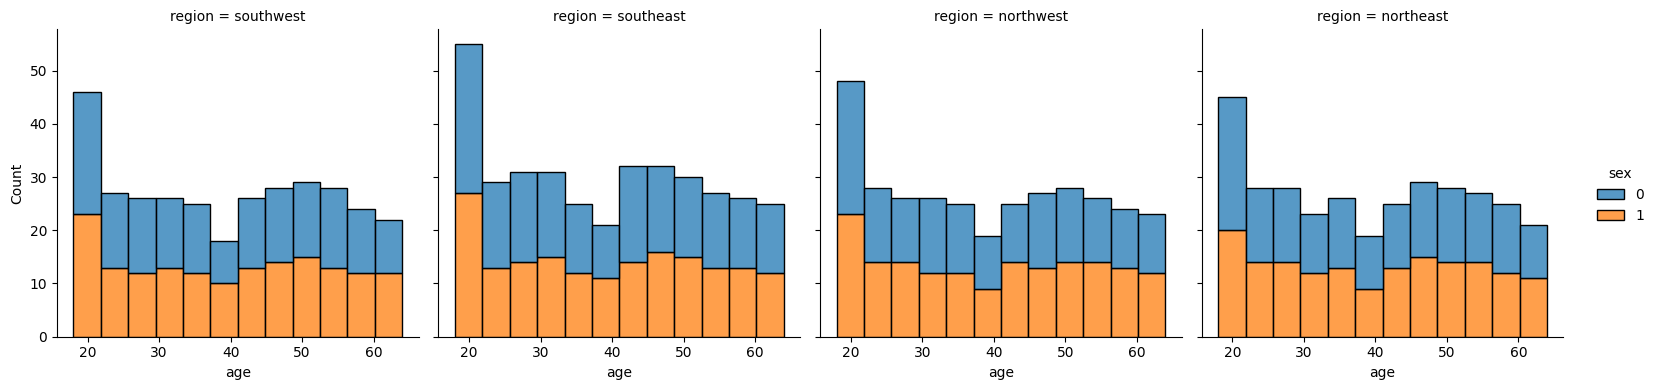

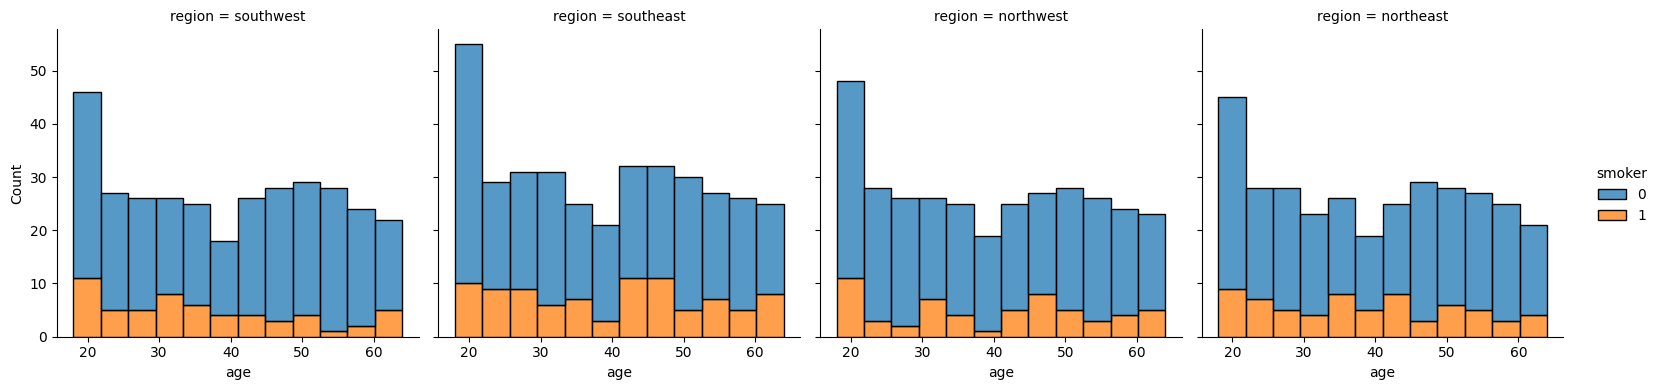

In [172]:
### Age distribution by sex and region
sns.displot(data=df, x='age', hue='sex', col='region', multiple='stack', height=4, aspect=1)

### Age distribution by smoker status and region
sns.displot(data=df, x='age', hue='smoker', col='region', multiple='stack', height=4, aspect=1)

plt.show()

The graphs remain roughly the same in shape, thus there is no major inbalance of the variables age, sex, and smoker in terms of region. 

We proceed to look at the Body-Mass index (BMI) in conjunction with sex and smoker status.

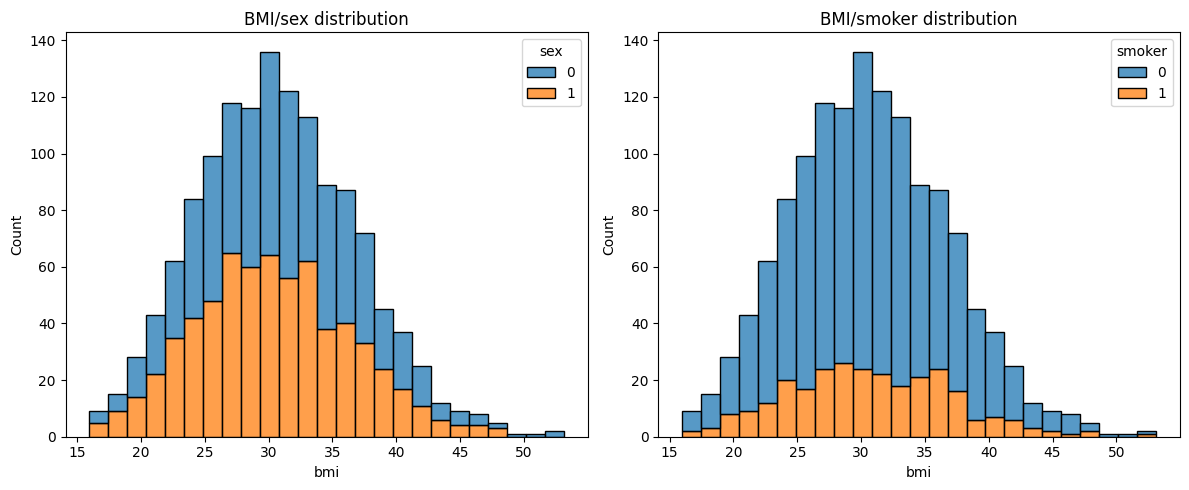

In [173]:
### Initialize axes
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

### BMI distribution and sex
sns.histplot(data=df, x='bmi', hue='sex', multiple = 'stack', ax=axes[0])
axes[0].set_title('BMI/sex distribution')

### BMI distribution and smoker status
sns.histplot(data=df, x='bmi', hue='smoker', multiple = 'stack', ax=axes[1])
axes[1].set_title('BMI/smoker distribution')

plt.tight_layout()
plt.show()

It seems that the dataset is roughly normally distributed around BMI 30. Female and Male individuals are balanced in terms of BMI. The same can be said for smoker status accounting for the relative percentage. 

Next we split the data by region.

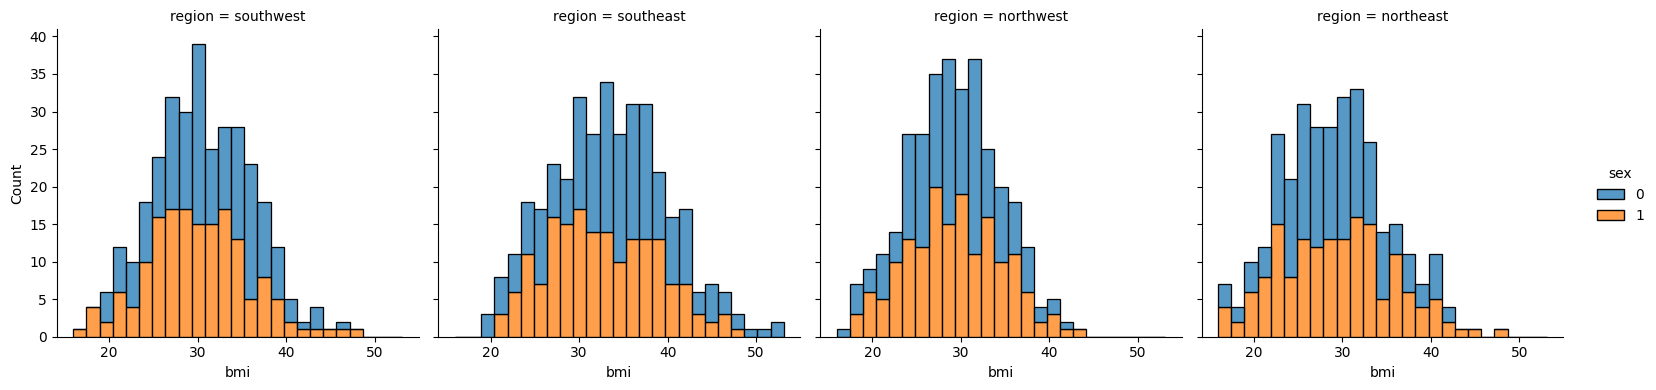

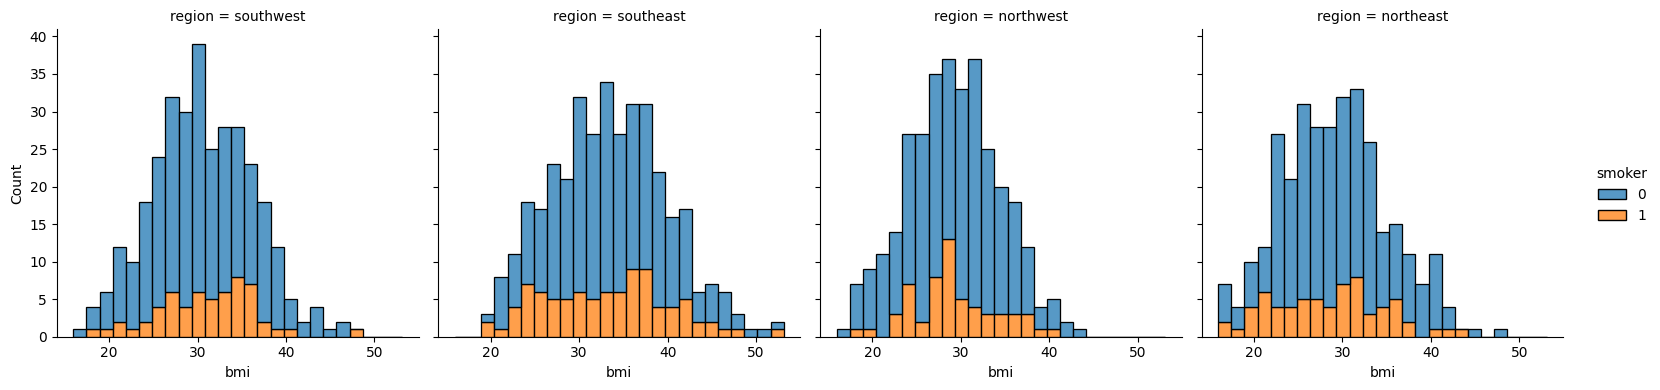

In [174]:
### BMI distribution by sex and region
sns.displot(data=df, x='bmi', hue='sex', col='region', multiple='stack', height=4, aspect=1)

### BMI distribution by smoker status and region
sns.displot(data=df, x='bmi', hue='smoker', col='region', multiple='stack', height=4, aspect=1)

plt.show()

The distributions by region seem to remain normal.

We continue by plotting the charges distribution.

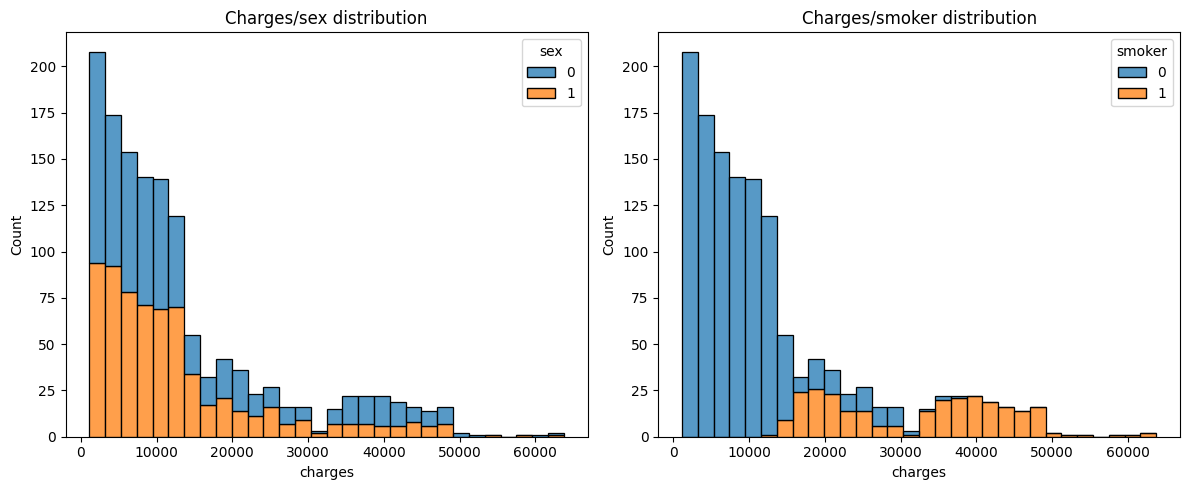

In [175]:
### Initialize axes
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

### Charges distribution and sex
sns.histplot(data=df, x='charges', hue='sex', multiple = 'stack', ax=axes[0])
axes[0].set_title('Charges/sex distribution')

### Charges distribution and smoker status
sns.histplot(data=df, x='charges', hue='smoker', multiple = 'stack', ax=axes[1])
axes[1].set_title('Charges/smoker distribution')

plt.tight_layout()
plt.show()

The charges distribution is heavily left skewed, indicating that most individuals have relatively lower charges. From the graph on the left we see that sex does not seem to influence individuals charges. From the graph on the right we see that the majority of the high charges individuls are smokers. This aligns with our intuition gained from the correlation matrix, stating that charges are highly correlated with smoker status. 

Next we check whether region plays a role on this distribution.

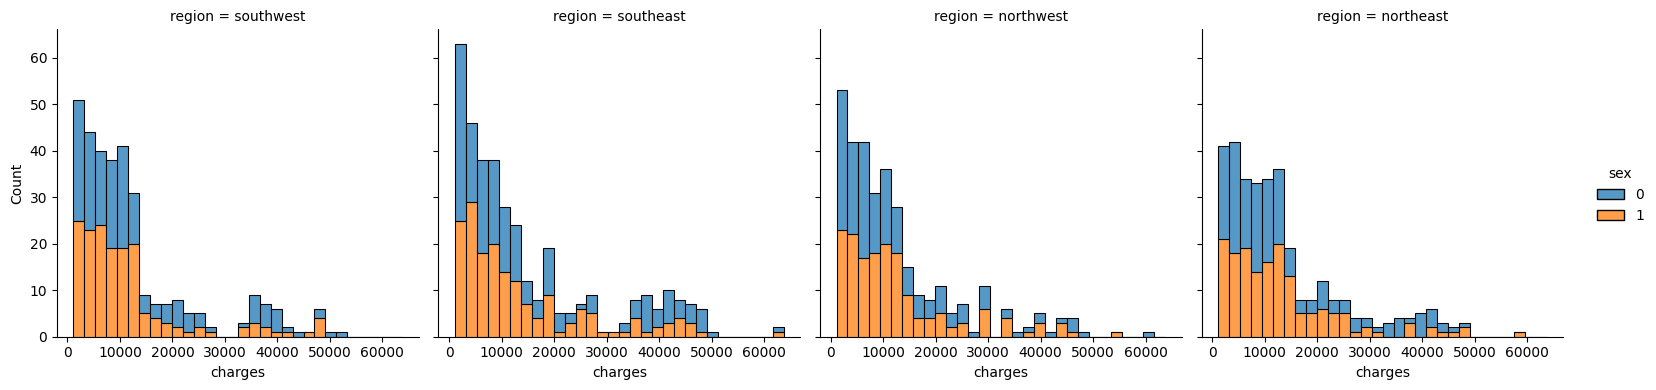

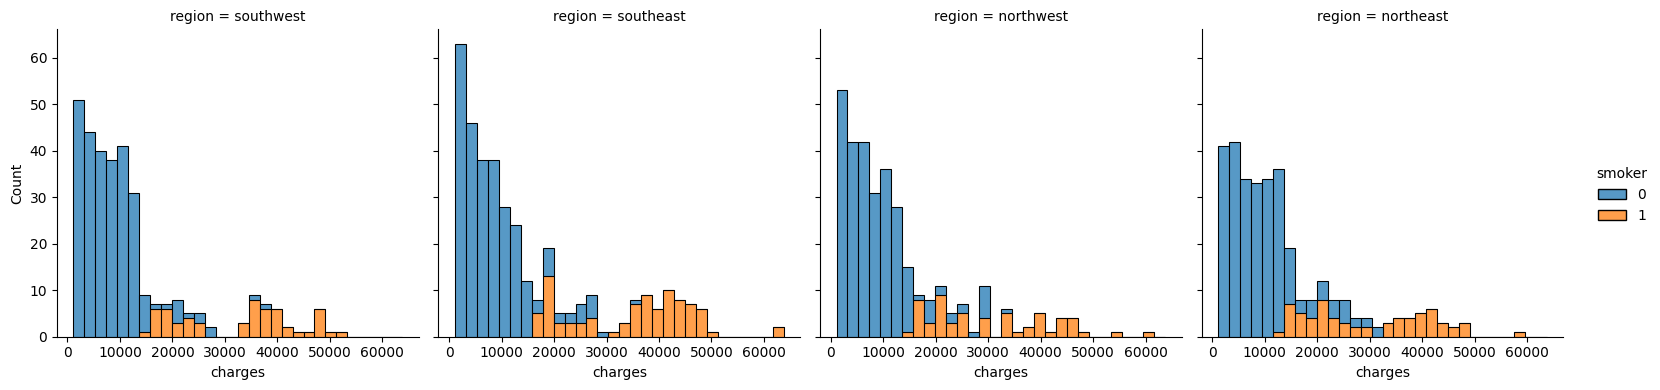

In [176]:
### Charges distribution by sex and region
sns.displot(data=df, x='charges', hue='sex', col='region', multiple='stack', height=4, aspect=1)

### Charges distribution by smoker status and region
sns.displot(data=df, x='charges', hue='smoker', col='region', multiple='stack', height=4, aspect=1)

plt.show()

There seem to be higher charges in the southeast compared to other regions. We will verify it by plotting it explicitly.

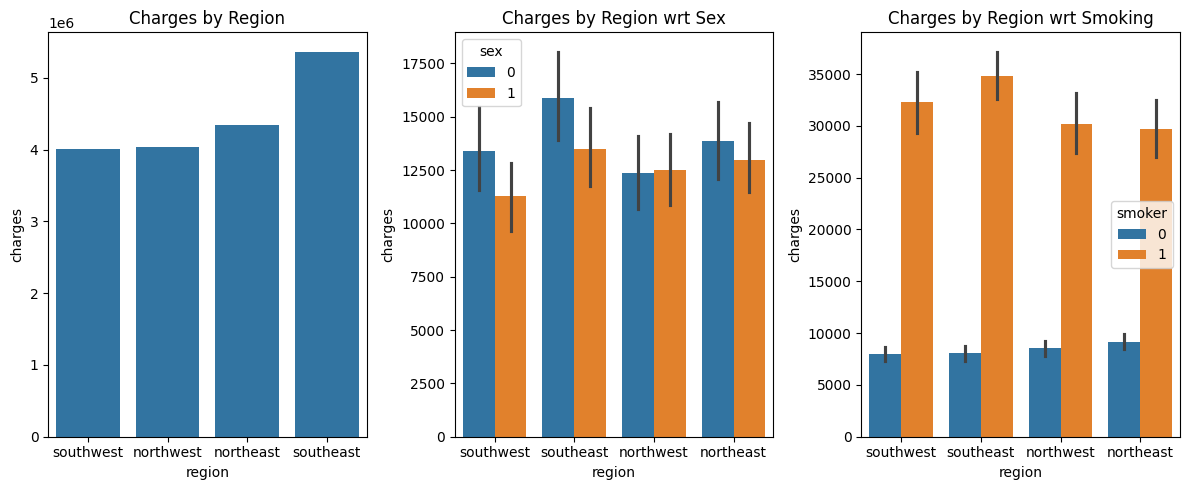

In [177]:
### Initialize axes
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

### Charges by region in ascending order
charges = df['charges'].groupby(df.region).sum().sort_values(ascending = True)
sns.barplot(data = charges, ax = axes[0])
axes[0].set_title('Charges by Region')

### Charges by region with respect to sex
sns.barplot(data=df, x='region', y ='charges', hue = 'sex', ax=axes[1])
axes[1].set_title('Charges by Region wrt Sex')

### Charges by region with respect to smoking
sns.barplot(data=df, x='region', y ='charges', hue = 'smoker', ax=axes[2])
axes[2].set_title('Charges by Region wrt Smoking')

plt.tight_layout()
plt.show()



We see indeed that the there correspond more charges in the southeast than elsewhere. This might be because regions with more individuals naturally have higher total charges. We factor that in by taking the average charges per person by region.

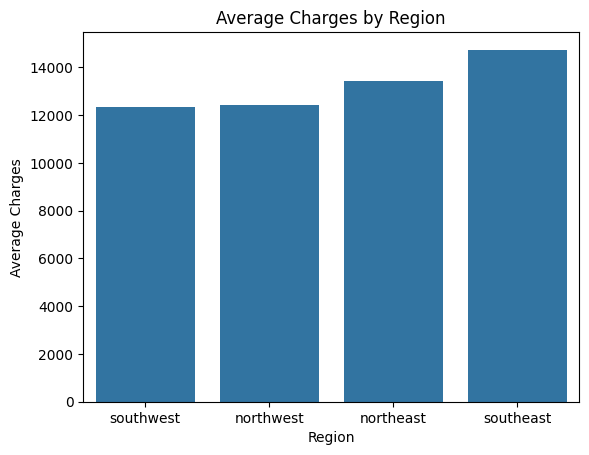

In [178]:
### Average charges per person by region
charges_per_person = (df.groupby('region')['charges'].mean().sort_values(ascending=True))

sns.barplot(x=charges_per_person.index, y=charges_per_person.values)

plt.title('Average Charges by Region')
plt.xlabel('Region')
plt.ylabel('Average Charges')
plt.show()

This graph demonstrates that individuals in the southeast indeed have higher charges than in other regions. 

Next we check what influence the number of children of each individual has on charges. First we plot the distribution of number of children. 

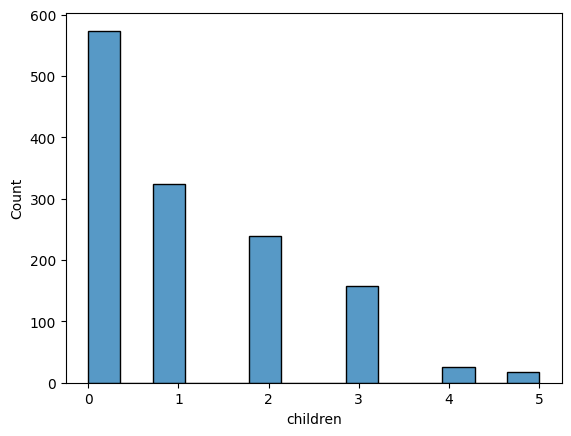

In [179]:
### Distribution of number of children
sns.histplot(data=df, x='children')

plt.show()

Most people do not have any children, while overall we see a left skewed distribution, which is to be expected, especially considering that there is a large number of young individuals. 

We also produce a violin plot of charges by region with respect to number of children.

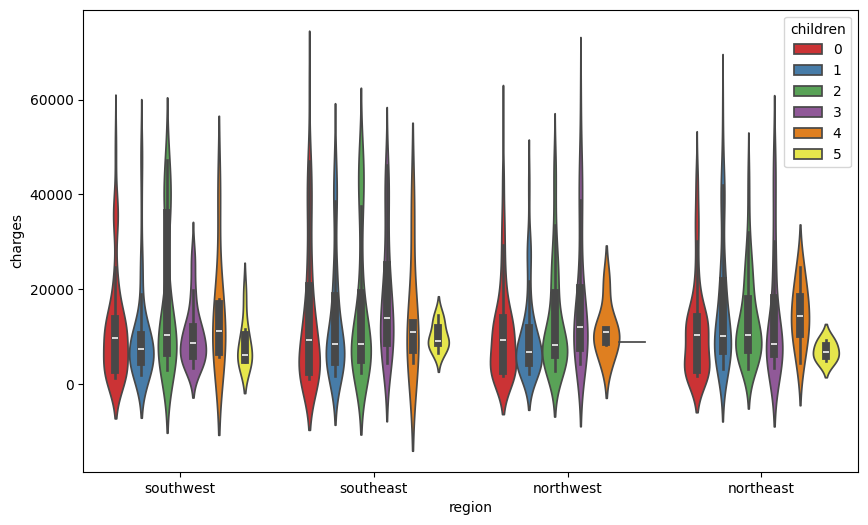

In [180]:
### Initialize axis
fig,ax = plt.subplots(1, 1, figsize=(10, 6)) 

### Charges by region with respect to number of children
sns.violinplot(data=df, x='region', y='charges', hue='children', palette='Set1', inner='box')

plt.show()

It seems that average charges do not vary a lot with respect to number of children regardless of the region.

We move to studying the charges by age by looking at scatterplots. We also incorporate sex, age and number of children into the scatterplots.

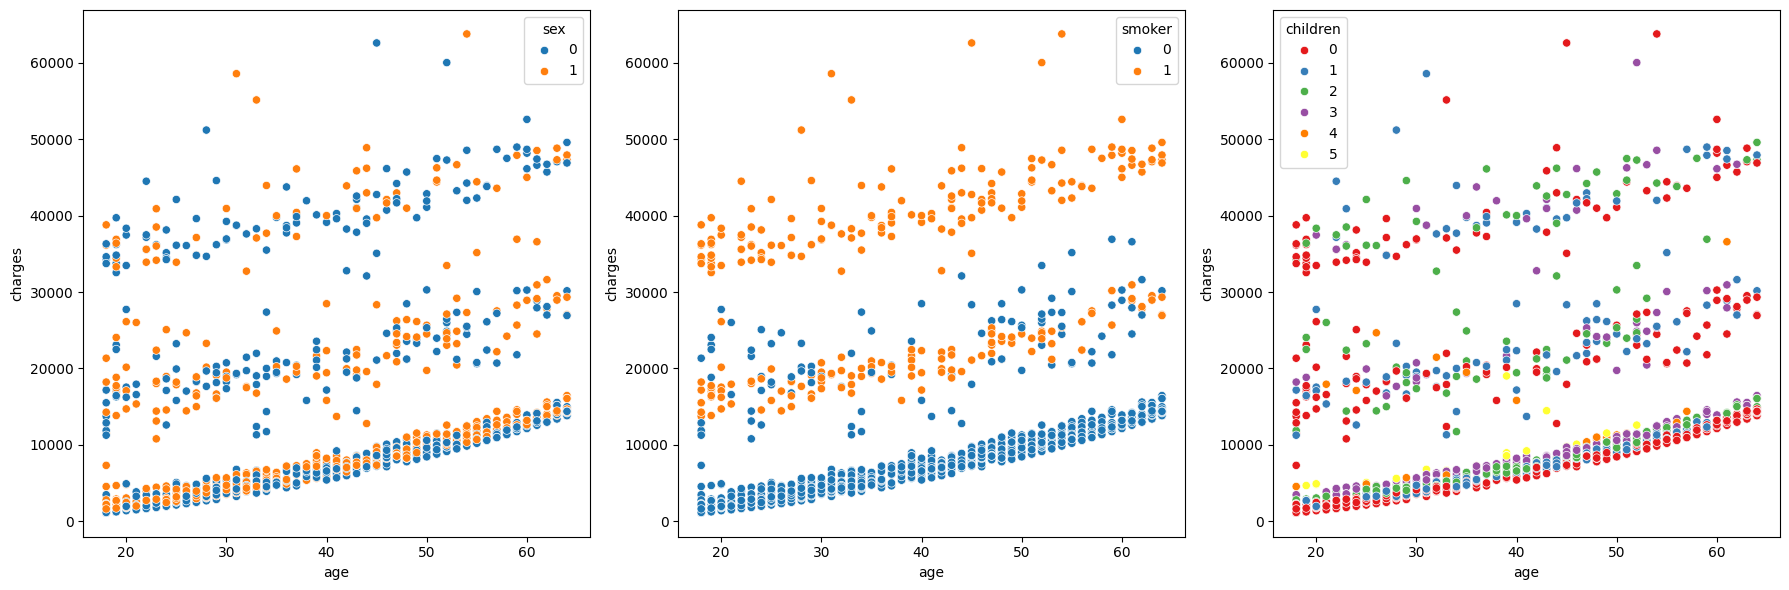

In [181]:
### Initialize axes
fig,axes = plt.subplots(1, 3, figsize=(18,6)) 

### Charges by age with respect to sex
sns.scatterplot(df, x = 'age', y='charges',hue = 'sex', ax = axes[0])

### Charges by age with respect to smoking
sns.scatterplot(df, x = 'age', y='charges',hue = 'smoker', ax = axes[1])

### Charges by age with respect to number of children
sns.scatterplot(df, x = 'age', y='charges',hue = 'children', palette='Set1',ax = axes[2])

plt.tight_layout()
plt.show()

We notice 3 facts. Fistly, there seem to be 3 distinct trend groups that, each group having distinct average charges. Secondly, these average charges increase by age. Finally, the middle plot indicates that the one of the groups, the one with the highest average charges, is made up entirely of smokers. We investigate the middle plot further. 

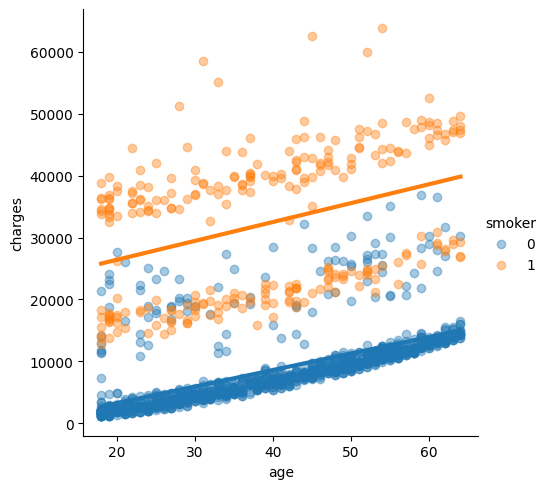

In [182]:
### Charges by age with respect to smoking with regression line
sns.lmplot(data=df, x='age', y='charges', hue='smoker', ci=None, scatter_kws={'alpha': 0.4}, line_kws={'linewidth': 3})

plt.show()

It is clear that smokers have different charges than non smokers. The points in the middle of the main two clusters are mixed between smokers and non-smokers. It is not clear whether there is another factor producing this splitting or whether this is a cluster produced by outliers from either group, smokers and non-smokers. We will investigate BMI to further our understanding. We categorize individuals by weight by making bins.

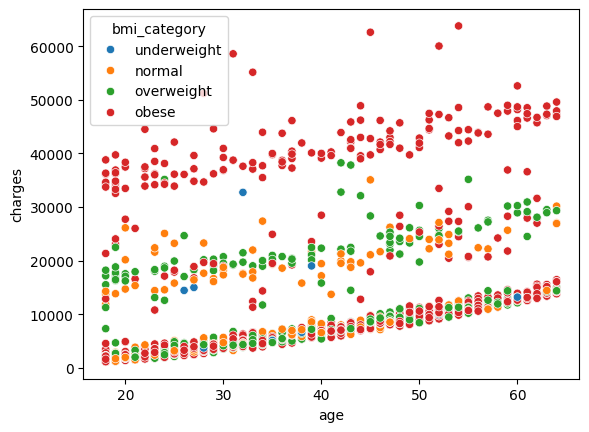

In [183]:
### Copy data to create BMI categories
df_bmi_copy = df.copy()

### Make bins and labels for BMI categories
bins = [0, 18.5, 25, 30, float("inf")]
labels = ["underweight", "normal", "overweight", "obese"]

### Create BMI categories
df_bmi_copy["bmi_category"] = pd.cut(df_bmi_copy["bmi"], bins=bins, labels=labels)

### Charges by age with respect to BMI category
sns.scatterplot(data=df_bmi_copy, x='age', y='charges', hue='bmi_category', hue_order=labels)

plt.show()

From this plot we see that the individuals with the highest average charges are not only smokers, as indicated before, but also obese. We filter by obese individuals to see whether there is a significant number of obese people with low average charges.

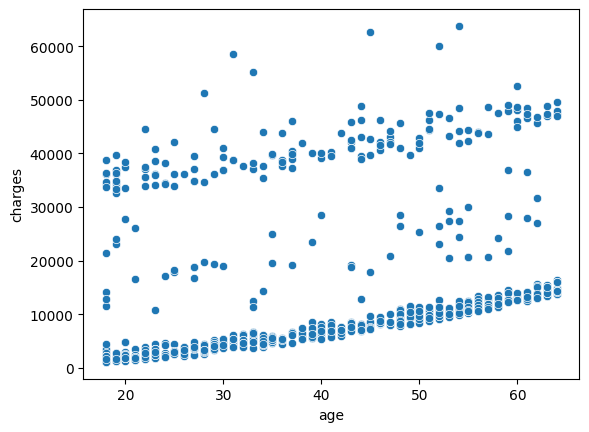

In [184]:
### Filter for obese category
obese_df = df_bmi_copy[df_bmi_copy["bmi_category"] == "obese"]

### Charges by age with respect to obese category
sns.scatterplot(data=obese_df, x='age', y='charges')

plt.show()

Apparently being obese is not the only factor for high charges, but taking into consideration the smoking status it is probably a combination of both. In the following graph we will see whether amongst obese individuals we can separate the two visible clusters by smoker status.

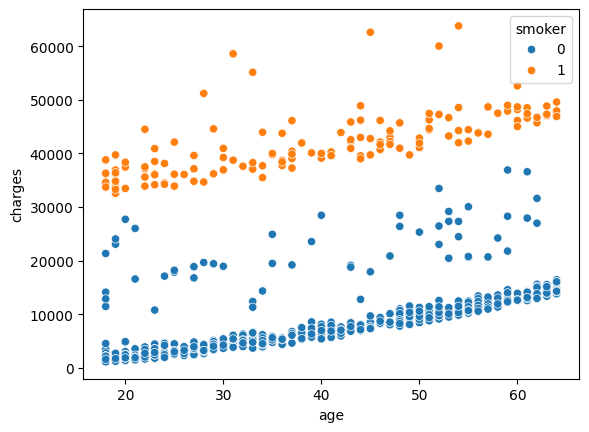

In [185]:
### Charges by age with respect to obese category and smoking status
sns.scatterplot(data=obese_df, x='age', y='charges', hue='smoker')

plt.show()

Indeed the highest charges of obese individuals correspond to those who are also smokers. We will now see how charges are related to BMI. 

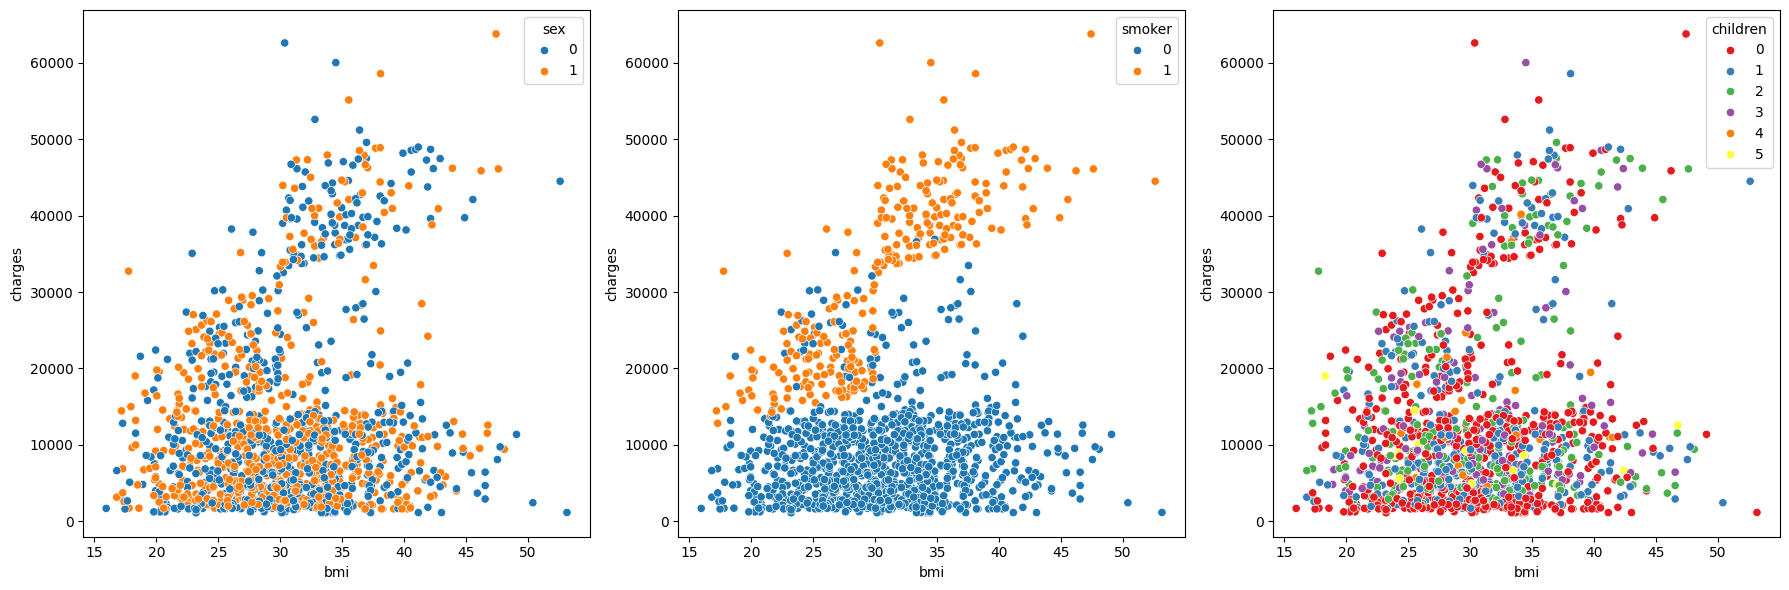

In [186]:
### Initialize axes
fig,axes = plt.subplots(1, 3, figsize=(18,6)) 

### charges by BMI with respect to sex
sns.scatterplot(df, x = 'bmi', y='charges',hue = 'sex', ax = axes[0])

### charges by BMI with respect to smoker status
sns.scatterplot(df, x = 'bmi', y='charges',hue = 'smoker', ax = axes[1])

### charges by BMI with respect to number of children
sns.scatterplot(df, x = 'bmi', y='charges',hue = 'children', palette='Set1', ax = axes[2])

plt.tight_layout()
plt.show()

Although sex and children seem to not show any particular pattern in the data, we can confirm what was previously seen for the smoker status. We investigate the middle graph further.

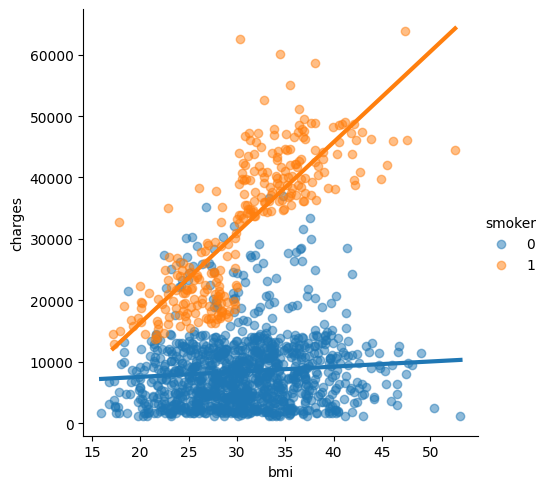

In [187]:
### charges by BMI with respect to smoker status with regression line
sns.lmplot(data=df, x='bmi', y='charges', hue='smoker', ci=None, scatter_kws={'alpha': 0.5}, line_kws={'linewidth': 3})

plt.show()

Although charges stay rouglhy constant when BMI increases for non-smokers, they increase dramatically for individuals who smoke. We saw before that this must be especially true for obese people. we verify this claim.

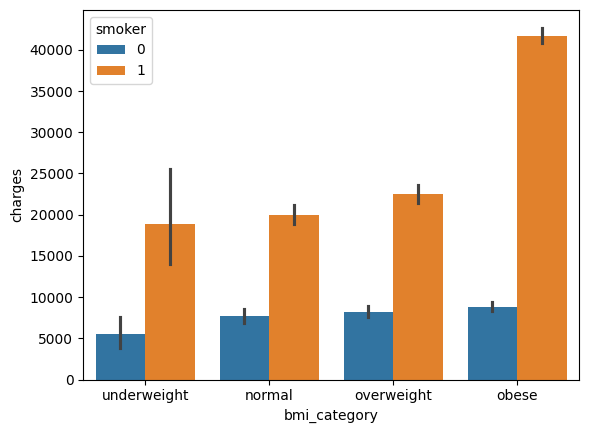

In [188]:
sns.barplot(data = df_bmi_copy, x='bmi_category', y='charges', hue = 'smoker')
plt.show()

From the above investigation we conclude that the most infuential factor for high charges is being an obese smoker.

## 4. Feature Engineering and Feature Selection

This section aims to improve predictive performance by transforming and enriching the original variables. Techniques such as logarithmic transformations, interaction terms, polynomial features, multicollinearity analysis using VIF, and heteroscedasticity diagnostics are applied to construct a more robust and statistically reliable regression model.

We firstly prepare the data for analyzing. We separate the predictors from the target.

In [189]:
### Separating data into predictors and target variables
X = df.drop(columns = 'charges')
y = df['charges']


We split the data into training and test set. We choose a 80-20 split which is a standard choice.

In [190]:
### Splitting data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

We perform some necessary preprocessing to our data. Firstly, we produce dummy variables to encode the region. Next Next, we align the columns from the training and test set. We make copies of the raw data before performing feature engineering.

In [191]:
### Encoding for region variable
if 'region' in X_train.columns:
    X_train = pd.get_dummies(X_train, columns=["region"], drop_first=True, dtype=int)
    X_test = pd.get_dummies(X_test, columns=["region"], drop_first=True, dtype=int)

### Align columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
X_test = X_test[X_train.columns]

### Make copies of raw features before feature engineering
X_train_raw = X_train.copy()
X_test_raw = X_test.copy() 
y_train_raw = y_train.copy()
y_test_raw = y_test.copy()

Since we will be using OLS from statsmodels we need to manually add the regression constant into our dataset. This will not be necessary later, when sklearn models will be used, where the regression constant is added automatically.

In [192]:
### Adding constant for regression
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)

The following function can be used to check the proportion of variables in the data. Since the data is split randomly it could be that there are no smokers in the test set. With this function we can check that manually.

In [193]:
### Function to compare proportions of variables
def compare_proportions(X_train, X_test):
    summary = {}

    for col in X_train.columns:
        train_dist = X_train[col].value_counts(normalize=True, dropna=False)
        test_dist  = X_test[col].value_counts(normalize=True, dropna=False)
        diff = np.abs(train_dist - test_dist)

        summary[col] = pd.DataFrame({
            'train': train_dist,
            'test': test_dist,
            'difference' : diff
        }).fillna(0)

    return summary

We check the smokers for instance.

In [194]:
### Check smokers 
proportions = compare_proportions(X_train, X_test)

proportions['smoker']

,train,test,difference
smoker,,,
0,0.794393,0.798507,0.004115
1,0.205607,0.201493,0.004115


We define an auxilliary function that plots the residuals, which will be extensively used in evaluating our model.

In [195]:
def plot_resid(model):
    plt.scatter(model.fittedvalues, model.resid)
    plt.axhline(0, color='red')
    plt.xlabel("Fitted values")
    plt.ylabel("Residuals")
    plt.title("Residual Plot")
    plt.show()

Feature engineering is performed according to the following scheme. The model is fit and residuals are plotted. A transformation is applied and the goal is to improve R^2 and obtain normally distributed residuals as well as remove heteroscedasticity. This procedure will not yield perfect results and adding too many features comes with drawbacks, such as stong multicolinearity. We start by fitting an initial model.

In [196]:
### Fitting initial model
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     380.9
Date:                Fri, 29 May 2026   Prob (F-statistic):          1.32e-305
Time:                        17:54:24   Log-Likelihood:                -10845.
No. Observations:                1070   AIC:                         2.171e+04
Df Residuals:                    1061   BIC:                         2.175e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.195e+04   1121.021  

We plot the residuals.

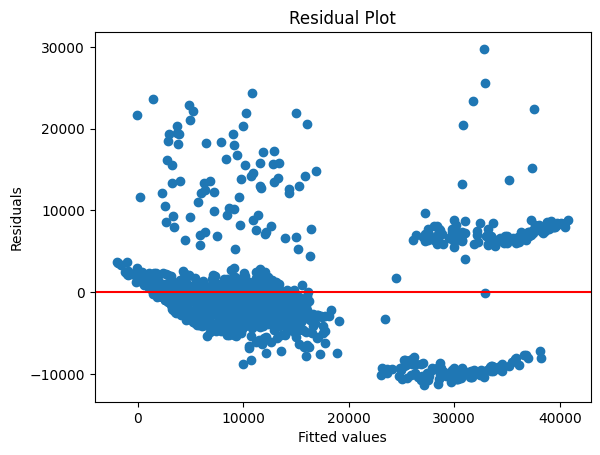

In [197]:
### Residual plot
plot_resid(model)

The left skew of the distribution of the target variable that was observed earlier suggests that the model might benefit from a logarithmic transformation. We will do that to all the continuous variables, namely charges and BMI. We initially verify that no values are negative, so that logarithms can be taken, and then we apply the transform to both training and test tests.

In [198]:
### Verify logarithm of bmi and charges can be taken
assert (X_train['bmi'] <= 0).sum() == 0
assert (y_train <= 0).sum() == 0

### Logarithmic transform of bmi
X_train['bmi'] = np.log(X_train['bmi'])
X_test['bmi'] = np.log(X_test['bmi'])

### Logarithmic transform of charges
y_train = np.log(y_train)
y_test = np.log(y_test)

We evaluate this transformation.

In [199]:
### Fitting the model
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.758
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                     415.4
Date:                Fri, 29 May 2026   Prob (F-statistic):          1.44e-320
Time:                        17:54:24   Log-Likelihood:                -659.67
No. Observations:                1070   AIC:                             1337.
Df Residuals:                    1061   BIC:                             1382.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                5.9373      0.240  

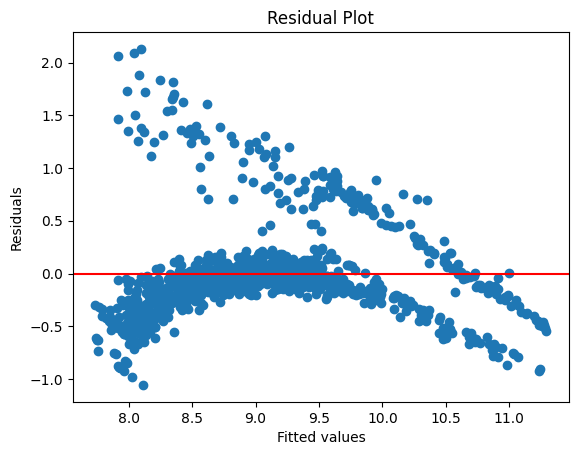

In [200]:
### Residual plot
plot_resid(model)

Since the residuals do no longer appear in four distinct clusters we keep the transform in place. We notice that the residuals appear in a n inverted U shape and a stripe with negative slope on top. There is also some heteroscedasticity on the left. We now incorporate our main previous observation from EDA, that is, smoker status and BMI influence medical charges jointly. We translate that into a new feature.

In [201]:
### Define new feature
X_train['smoker x bmi'] = X_train['smoker'] * X_train['bmi']
X_test['smoker x bmi'] = X_test['smoker'] * X_test['bmi']

We fit the new model.

In [202]:
### Fitting the model
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.772
Method:                 Least Squares   F-statistic:                     403.5
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        17:54:25   Log-Likelihood:                -622.95
No. Observations:                1070   AIC:                             1266.
Df Residuals:                    1060   BIC:                             1316.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                6.9633      0.260  

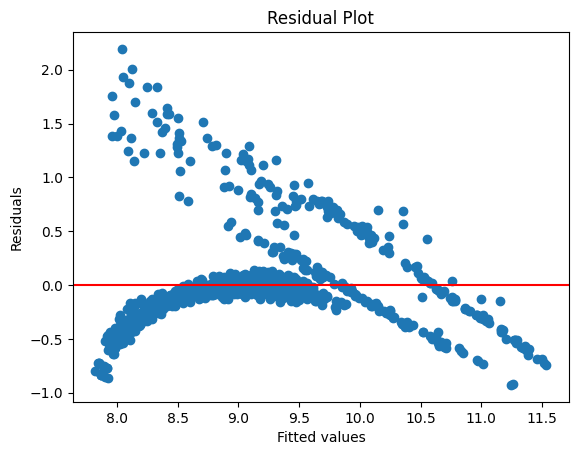

In [203]:
### Residual plot
plot_resid(model)

Although the shapes have become sharper, and the stripe has split into two, there seems to be no significant improvement to the overall shape. We will now incorporate the fact that obese smokers have higher overall charges. In order to do that we define a new feature called obese_smoker.

In [204]:
### Define new feature obese smoker (= 1 if obese smoker, = 0 if not)
X_train['obese_smoker'] = (X_train['bmi'] > np.log(30)) * X_train['smoker']
X_test['obese_smoker'] = (X_test['bmi'] > np.log(30)) * X_test['smoker']

We fit the model.

In [205]:
### Fitting the model
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.779
Model:                            OLS   Adj. R-squared:                  0.777
Method:                 Least Squares   F-statistic:                     374.2
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        17:54:25   Log-Likelihood:                -610.06
No. Observations:                1070   AIC:                             1242.
Df Residuals:                    1059   BIC:                             1297.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                6.9637      0.257  

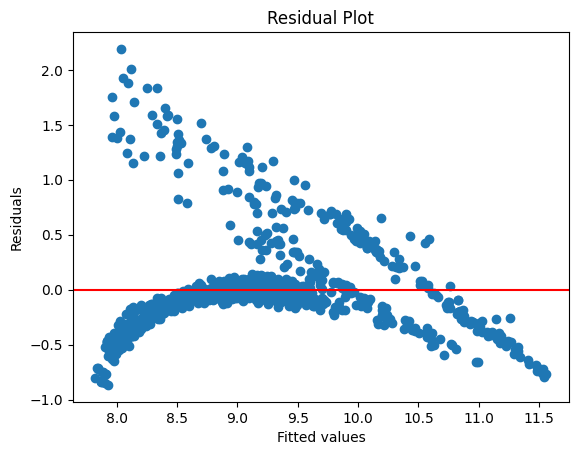

In [206]:
### Residual plot
plot_resid(model)

The model R^2 has overall improved from these additions, but there are still issues with the shape. In order to further explore we produce residuals plots with color hue indicating the change in each variable. This will give us indications as to which variable influences the shape.

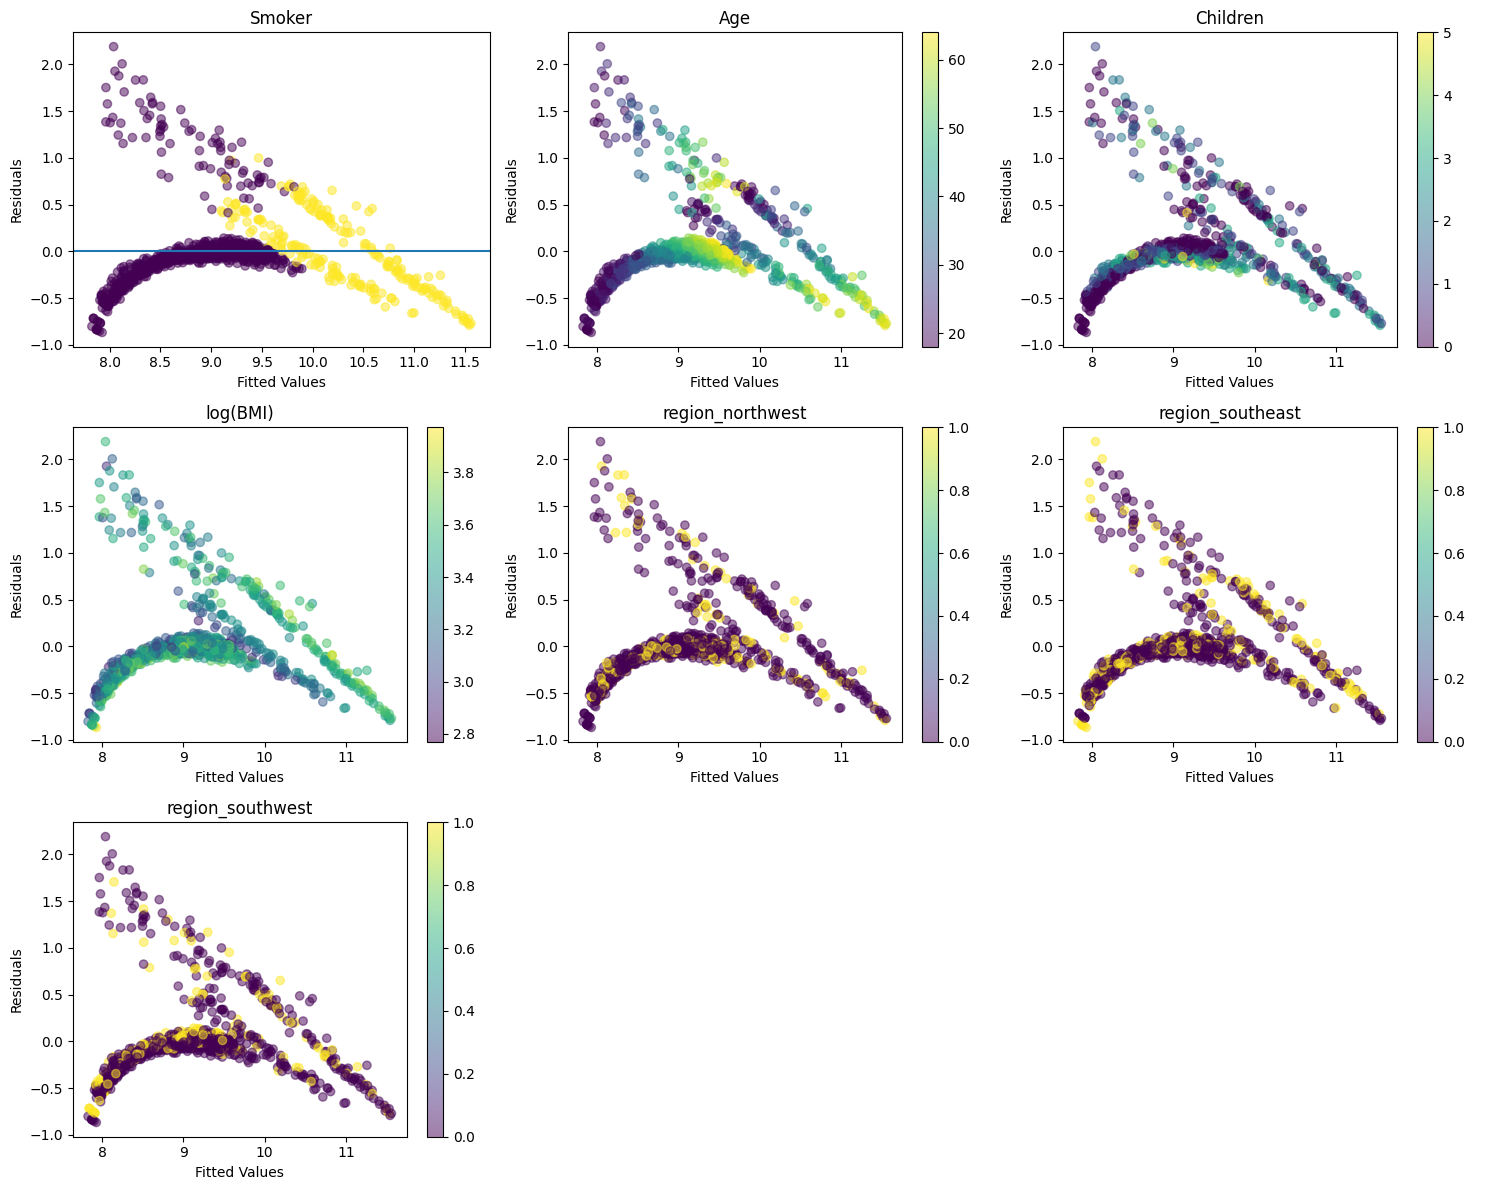

In [207]:
### Residual Plots with color dependence on feature
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# 1. Smoker
sc0 = axes[0].scatter(model.fittedvalues, model.resid, c=X_train['smoker'], alpha=0.5)
axes[0].axhline(0)
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title("Smoker")

# 2. Age
sc1 = axes[1].scatter(model.fittedvalues, model.resid, c=X_train['age'], alpha=0.5)
axes[1].set_xlabel('Fitted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title("Age")
fig.colorbar(sc1, ax=axes[1])

# 3. Children
sc2 = axes[2].scatter(model.fittedvalues, model.resid, c=X_train['children'], alpha=0.5)
axes[2].set_xlabel('Fitted Values')
axes[2].set_ylabel('Residuals')
axes[2].set_title("Children")
fig.colorbar(sc2, ax=axes[2])

# 4. BMI
sc3 = axes[3].scatter(model.fittedvalues, model.resid, c=X_train['bmi'], alpha=0.5)
axes[3].set_xlabel('Fitted Values')
axes[3].set_ylabel('Residuals')
axes[3].set_title("log(BMI)")
fig.colorbar(sc3, ax=axes[3])

# 5–7. Regions
region_cols = ['region_northwest', 'region_southeast', 'region_southwest']
for i, col in enumerate(region_cols, start=4):    
    sc = axes[i].scatter(model.fittedvalues, model.resid, c=X_train[col], alpha=0.5)
    axes[i].set_xlabel('Fitted Values')
    axes[i].set_ylabel('Residuals')
    axes[i].set_title(col)    
    fig.colorbar(sc, ax=axes[i])

# Hide unused subplots
for j in range(7, 9):    
    axes[j].axis('off')

plt.tight_layout()
plt.show()

As can be seen above, smoker status and age play the most important role. Since smoker status and BMI have been accounted for we shift our interest to age. We define a new feature to capture the cross interaction between smoker status and age.

In [208]:
### Define new feature smoker x age
X_train['smoker x age'] = X_train['smoker'] * X_train['age']
X_test['smoker x age'] = X_test['smoker'] * X_test['age']

We fit the model.

In [209]:
### Fitting the model
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     446.9
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        17:54:29   Log-Likelihood:                -492.67
No. Observations:                1070   AIC:                             1009.
Df Residuals:                    1058   BIC:                             1069.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                6.9456      0.231  

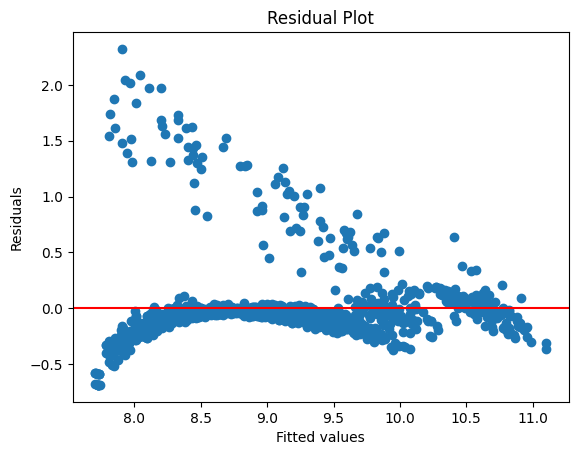

In [210]:
### Residual plot
plot_resid(model)

The new feature improves the shape. We explore quadratics terms next. Polynomial terms will be further included also in our Polynomial regression model later. We start with age^2.

In [211]:
### Define new feature age^2
X_train['age^2'] = X_train['age']**2
X_test['age^2'] = X_test['age']**2

We fit the model.

In [212]:
### Fitting the model
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.823
Method:                 Least Squares   F-statistic:                     415.6
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        17:54:29   Log-Likelihood:                -485.88
No. Observations:                1070   AIC:                             997.8
Df Residuals:                    1057   BIC:                             1062.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                6.5451      0.254  

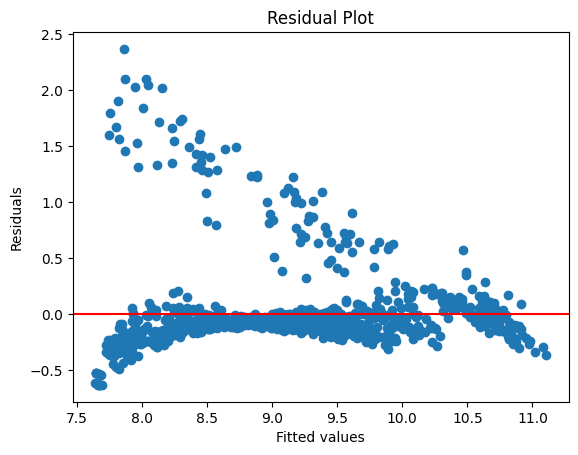

In [213]:
### Residual plot
plot_resid(model)

Now we add BMI^2.

In [214]:
### Define new feature bmi^2
X_train['bmi^2'] = X_train['bmi']**2
X_test['bmi^2'] = X_test['bmi']**2

In [215]:
### Fitting the model
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     385.0
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        17:54:30   Log-Likelihood:                -483.91
No. Observations:                1070   AIC:                             995.8
Df Residuals:                    1056   BIC:                             1065.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.5649      2.533  

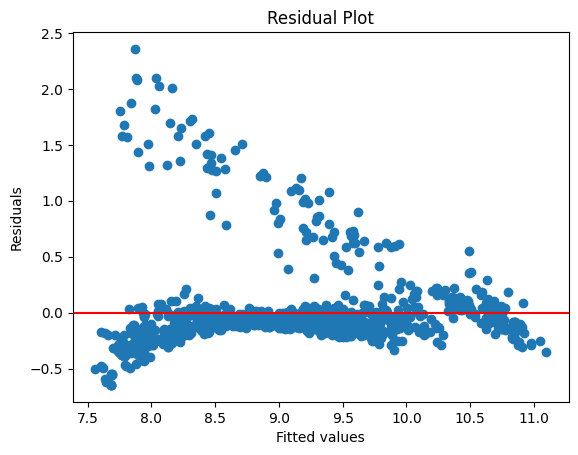

In [216]:
### Residual plot
plot_resid(model)

The shape has flattened, and R^2 has increased which suggest improvement. We check whether the target data would benefit from a Box-Cox transform instead of a logarithmic transform that was applied in the beginning.

In [217]:
### Transform data back into original scale
y_train_original = np.exp(y_train)

### Find optimal Box-Cox transformation parameter
y_train_bc, lambda_opt = stats.boxcox(y_train_original)
print(f"\nOptimal lambda: {lambda_opt:.4f}")

### Apply transform
y_train_bc = (y_train_original ** lambda_opt - 1) / lambda_opt


Optimal lambda: 0.0593


In [218]:
### Fitting the model
model_bc = sm.OLS(y_train_bc, X_train).fit()
print(model_bc.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.828
Model:                            OLS   Adj. R-squared:                  0.826
Method:                 Least Squares   F-statistic:                     390.9
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        17:54:30   Log-Likelihood:                -1053.9
No. Observations:                1070   AIC:                             2136.
Df Residuals:                    1056   BIC:                             2205.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.3874      4.316  

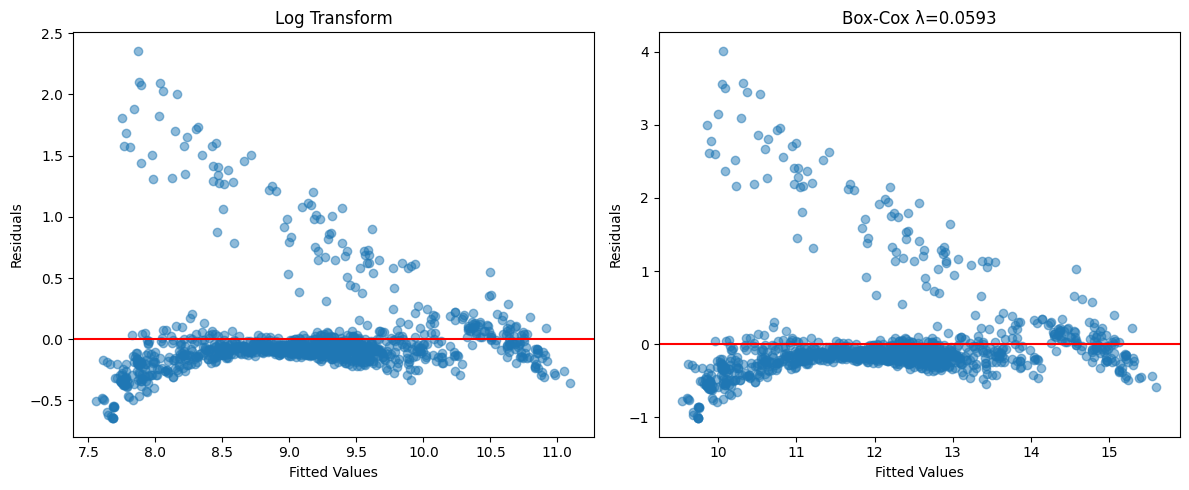

In [219]:
# Compare residuals (they will be nearly identical)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(model.fittedvalues, model.resid, alpha=0.5)
ax1.axhline(0, color='red')
ax1.set_xlabel('Fitted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('Log Transform')

ax2.scatter(model_bc.fittedvalues, model_bc.resid, alpha=0.5)
ax2.axhline(0, color='red')
ax2.set_xlabel('Fitted Values')
ax2.set_ylabel('Residuals')
ax2.set_title(f"Box-Cox λ={lambda_opt:.4f}")

plt.tight_layout()
plt.show()

The model does not seem to benefit from a Box-Cox transform significantly, and loses the appeal of log-transform's simplicity, so we abandon this approach. We additionally apply Heteroscedasticity-Robust Standard Errors to try to correct the heteroscedasticity that is visible for low Fitted values.

In [220]:
### Fitting the model
model = sm.OLS(y_train, X_train).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.824
Method:                 Least Squares   F-statistic:                     683.2
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        17:54:31   Log-Likelihood:                -483.91
No. Observations:                1070   AIC:                             995.8
Df Residuals:                    1056   BIC:                             1065.
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                1.5649      2.268  

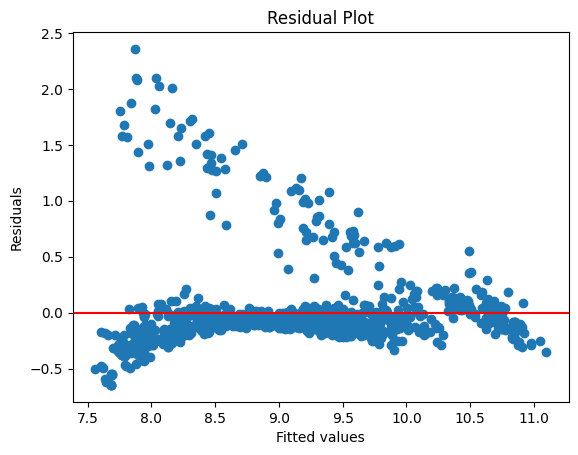

In [221]:
### Residual plot
plot_resid(model)

As was already noted by the model during feature engineering, multicolinearity has appear as a result of addition of multiple similar features. We do a multicoliniarity test using the Variance Inflation Factor (VIF).

In [222]:
### Initialize empty dataframe
vif = pd.DataFrame()

### Fill features column with feature names
vif['features'] = X_train.columns

### Fill VIF column with VIF values for each feature
vif['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]

### Sort values according to VIF score in descending order
vif.sort_values('VIF', ascending=False)

,features,VIF
0,const,46851.954382
9,smoker x bmi,688.234742
3,bmi,668.476149
13,bmi^2,668.114202
5,smoker,622.656595
1,age,47.883868
12,age^2,47.449258
11,smoker x age,8.735819
10,obese_smoker,5.510852
7,region_southeast,1.618931


We will remove a couple of features that influence multicolinearity strongly and that appeared to not have improved to model a lot. 
We choose bmi^2 ang age^2 that are already taken into account for by other features. Moreover these features will be accounted for in a Polynomial model later.

In [223]:
X_train = X_train.drop(columns = ['bmi^2','age^2'])
X_test = X_test.drop(columns = ['bmi^2','age^2'])

print(X_train.columns)

Index(['const', 'age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest',
       'region_southeast', 'region_southwest', 'smoker x bmi', 'obese_smoker',
       'smoker x age'],
      dtype='object')


We fit the final model.

In [64]:
### Fitting the final model
model = sm.OLS(y_train, X_train).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.821
Method:                 Least Squares   F-statistic:                     766.1
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        17:12:32   Log-Likelihood:                -492.67
No. Observations:                1070   AIC:                             1009.
Df Residuals:                    1058   BIC:                             1069.
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                6.9456      0.249  

We now have a sound initial model that incorporates our observations in the data as new features and that accounts for heteroscedasticity and some multicolinearity. 

## 5. Modeling and Evaluation 

This section develops and compares several statistical and machine learning models for predicting insurance charges. Models including OLS, LASSO, Ridge Regression, Polynomial Regression, and Random Forests are evaluated using cross-validation and performance metrics such as RMSE, MAE, and R² to assess predictive accuracy and generalization performance.

### 5.1. Evaluation Functions

We define some auxilliary function to help with model evaluation.

This following function performs K-Fold cross-validation by repeatedly training the model on different subsets of the data and evaluating it using RMSE on the validation folds. If the target variable was log-transformed, predictions and true values are converted back to the original scale before computing the error. Cross-validation is performed manually because of target scaling, which influences how RMSE is calculated.

In [65]:
def cross_val_rmse(model, X, y, n_splits=5, log = True):

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    rmse_scores = []

    for train_idx, val_idx in kf.split(X):

        X_tr = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_tr = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        model_clone = clone(model)

        model_clone.fit(X_tr, y_tr)

        y_pred = model_clone.predict(X_val)

        ### If log transformed data needs back transformation
        if log == True:
            y_pred = np.exp(y_pred)
            y_true = np.exp(y_val)
        
        else:
            y_true = y_val

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        rmse_scores.append(rmse)

    return np.mean(rmse_scores)

This function evaluates a model’s predictive performance using cross-validation, training-set metrics, and test-set metrics including RMSE, MAE, and R². It also handles the back-transformation of log-transformed targets and predictions so that all evaluation metrics are computed on the original target scale.

In [66]:
def evaluate_model(pipe, X_train, X_test, y_train, y_test, log = True, name = ''):

    ### List to store scores    
    scores = []

    ### If no name provided manually, use model class name   
    if name == '':
        name =pipe.named_steps['model'].__class__.__name__

    ### Calculate CV RMSE
    CV_RMSE = cross_val_rmse(pipe, X_train, y_train, log = log, n_splits = 5)
    scores.append(CV_RMSE)

    ### If log transformed data needs back transformation
    if log: 
        ### Predictions in log-space
        y_train_pred_log = pipe.predict(X_train)
        y_test_pred_log = pipe.predict(X_test)

        ### Back-transform predictions
        y_train_pred = np.exp(y_train_pred_log)
        y_test_pred = np.exp(y_test_pred_log)

        ### Back-transform true targets
        y_train_true = np.exp(y_train)
        y_test_true = np.exp(y_test)

    ### Otherwise no need for that
    else:
        y_train_pred = pipe.predict(X_train)
        y_test_pred = pipe.predict(X_test)

        y_train_true = y_train
        y_test_true = y_test

    # Metrics
    train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))
    scores.append(train_rmse)
    test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))
    scores.append(test_rmse)

    train_mae = mean_absolute_error(y_train_true, y_train_pred)
    scores.append(train_mae)
    test_mae = mean_absolute_error(y_test_true, y_test_pred)
    scores.append(test_mae)

    train_r2 = r2_score(y_train_true, y_train_pred)
    scores.append(train_r2)
    test_r2 = r2_score(y_test_true, y_test_pred)
    scores.append(test_r2)

    print(f"\n{name}")
    print("-" * 40)

    print("Train:")
    print(f"CV RMSE: {CV_RMSE:.4f}")
    print(f"RMSE: {train_rmse:.2f}")
    print(f"MAE:  {train_mae:.2f}")
    print(f"R²:   {train_r2:.4f}")

    print("\nTest:")
    print(f"RMSE: {test_rmse:.2f}")
    print(f"MAE:  {test_mae:.2f}")
    print(f"R²:   {test_r2:.4f}")

    return scores

This function visualizes model performance on the test set by plotting residuals, checking for heteroscedasticity, and comparing actual versus predicted values. These diagnostic plots help assess prediction accuracy and identify potential issues such as non-constant variance or systematic prediction errors.

In [67]:
def graph_residuals(pipe, X_test, y_test, name = ''):

    ### If no name provided manually, use model class name   
    if name == '':
        name = pipe.named_steps['model'].__class__.__name__

    
    ### Predict on test set
    y_test_pred = pipe.predict(X_test)

    ### True values of test set
    y_test_true = y_test

    ### Define residuals
    residuals_test = y_test_true - y_test_pred

    ### Initialize subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ### Residual plot on test set
    axes[0].scatter(y_test_pred, residuals_test, alpha=0.5)
    axes[0].axhline(0)
    axes[0].set_xlabel('Predicted Values')
    axes[0].set_ylabel('Residuals')
    axes[0].set_title('Residual Plot (Test set)')

    ### Heteroscedasticity check on test set
    axes[1].scatter(y_test_pred, np.abs(residuals_test), alpha=0.5)
    axes[1].set_xlabel("Predicted values")
    axes[1].set_ylabel("|Residuals|")
    axes[1].set_title("Heteroscedasticity Check")

    ### Actual vs Predicted on test set
    axes[2].scatter(y_test_true, y_test_pred, alpha=0.5)
    axes[2].plot([y_test_true.min(), y_test_true.max()], [y_test_true.min(), y_test_true.max()])
    axes[2].set_xlabel("Actual")
    axes[2].set_ylabel("Predicted")
    axes[2].set_title("Actual vs Predicted")

    plt.show()

Since we are using sklearn models for evaluation we will be dropping the previously added constant column from the predictors set. Sklearn automatically adds an intercept.

In [68]:
X_train = X_train.drop(columns='const')
X_test = X_test.drop(columns='const')

We define a dataframe to keep track of the metrics of each trained model.

In [69]:
### Columns for the dataframe
columns = ['Model', 'CV_RMSE', 'Train_RMSE', 'Test_RMSE', 'Train_MAE', 'Test_MAE', 'Train_R2', 'Test_R2']

### Initialize empty dataframe to store results
results = pd.DataFrame(columns=columns)

### Make Model name the index
results = pd.DataFrame(columns=columns).set_index('Model')

In the following sections we implement each model evaluate it. The workflow consists of training the model, printing the coefficients of each model (feature importance is calculated for the Random Forest Regressor instead), calculating and printing the evaluation metrics with the help of the  evaluate_model function, and finally plotting the residuals, checking for heteroscedasticity and plotting actual vs predicted values with the help of the graph_residuals function. 

### 5.2. OLS

We implement the Ordinary Least Squares model on the feature engineered test set.

In [70]:
### Initialize pipeline
pipe_ols = Pipeline([
    ('model', LinearRegression())
])

### Fit model on training data
pipe_ols.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


We present the coefficients of the regression.

In [71]:
### OLS coefficients
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": pipe_ols.named_steps["model"].coef_
}).sort_values("coef", key=abs, ascending=False)

### OLS intercept
intercept_df = pd.DataFrame({
    "feature": ["intercept"],
    "coef": [pipe_ols.named_steps["model"].intercept_]
})

### Add everything in the same dataframe
full_df = pd.concat([intercept_df, coef_df], ignore_index=True)

### Print dataframe
full_df

,feature,coef
0,intercept,6.945590
1,smoker x bmi,0.629874
2,obese_smoker,0.504541
3,smoker,0.442418
4,region_southwest,-0.158669
5,region_southeast,-0.123852
6,children,0.102165
7,sex,0.086288
8,region_northwest,-0.060716
9,bmi,0.044480


We calculate evaluation metrics, and plot the residuals.


LinearRegression
----------------------------------------
Train:
CV RMSE: 4962.6731
RMSE: 4949.64
MAE:  2460.56
R²:   0.8303

Test:
RMSE: 4631.22
MAE:  2256.68
R²:   0.8618


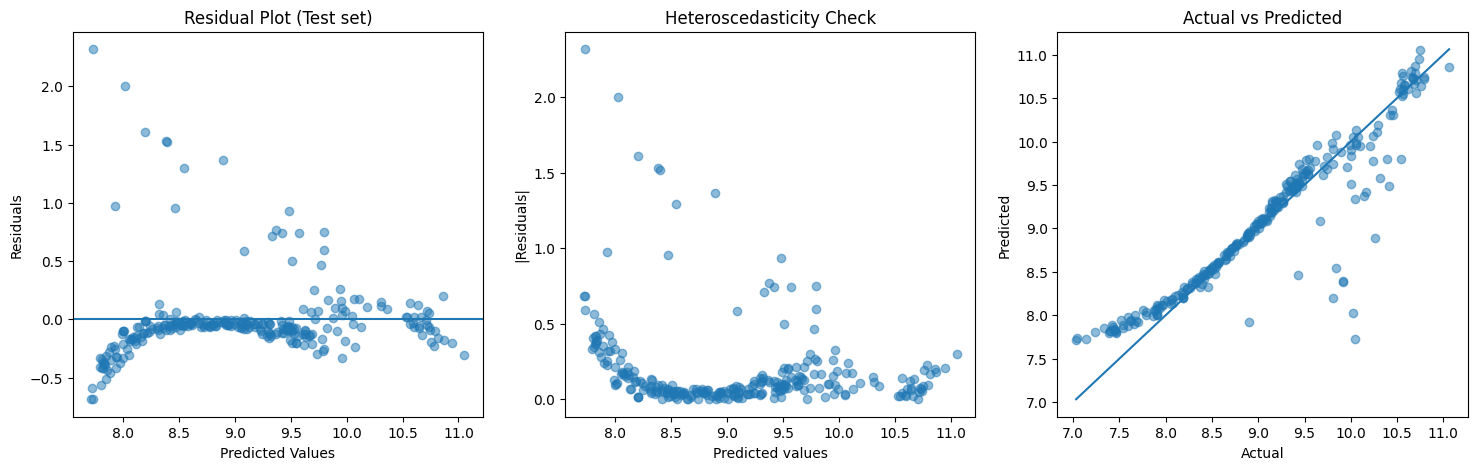

In [ ]:
### Model Evaluation
scores = evaluate_model(pipe_ols, X_train, X_test, y_train, y_test, log = True)

### Add scores to results dataframe
results.loc['OLS'] = scores

### Graph residuals
graph_residuals(pipe_ols, X_test, y_test)

### 5.3. LASSO

We implement the LASSO model on the feature engineered set.

In [73]:
### Initialize pipeline
pipe_lasso = Pipeline([
     ('scaler', StandardScaler()),
    ('model', LassoCV(cv = 5, n_jobs = -1, random_state = random_state, max_iter=10000))
])

### Fit model on training data
pipe_lasso.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True


We present the Lasso alpha coefficient and coefficients of the regression.

In [ ]:
### Print Lasso alpha hypermeter value
print(f'Lasso alpha: {pipe_lasso.named_steps["model"].alpha_:.4f}')
print('-'*40)

### Lasso coefficients
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": pipe_lasso.named_steps["model"].coef_
}).sort_values("coef", key=abs, ascending=False)

### Lasso intercept
intercept_df = pd.DataFrame({
    "feature": ["intercept"],
    "coef": [pipe_lasso.named_steps["model"].intercept_]
})

### Add everything in the same dataframe
full_df = pd.concat([intercept_df, coef_df], ignore_index=True)

### Print dataframe
full_df


Lasso alpha: 0.0006
----------------------------------------
             feature      coef
0          intercept  9.113322
1       smoker x bmi  0.817521
2                age  0.578901
3       smoker x age -0.550455
4             smoker  0.215417
5       obese_smoker  0.158976
6           children  0.123368
7   region_southwest -0.066279
8   region_southeast -0.052554
9                sex  0.042410
10  region_northwest -0.023924
11               bmi  0.008993


We calculate evaluation metrics, and plot the residuals.


LassoCV
----------------------------------------
Train:
CV RMSE: 4949.1494
RMSE: 4938.78
MAE:  2448.13
R²:   0.8310

Test:
RMSE: 4609.05
MAE:  2234.25
R²:   0.8632


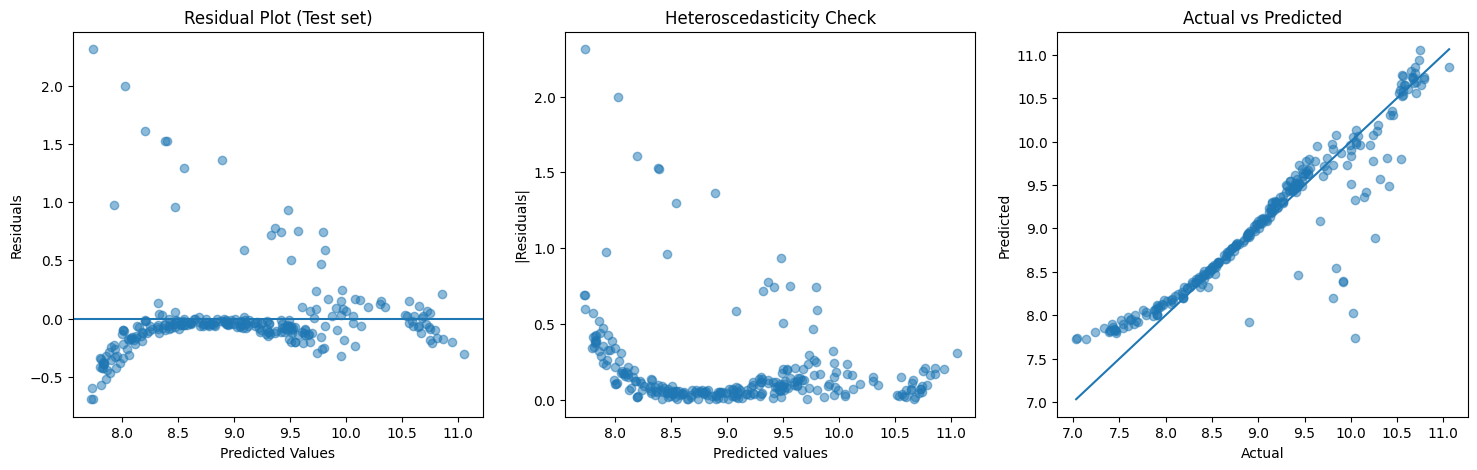

In [75]:
### Model Evaluation
scores = evaluate_model(pipe_lasso, X_train, X_test, y_train, y_test, log = True)

### Add scores to results dataframe
results.loc['LASSO'] = scores

### Graph residuals
graph_residuals(pipe_lasso, X_test, y_test)

### 5.4. Post-Lasso OLS

We implement an OLS model on the coefficients selected by the LASSO regression.

In [76]:
### Initialize pipeline
pipe_post_lasso = Pipeline([
    ('model', LinearRegression())
])

### Select features that were not shrunk to zero by Lasso   
selected_features = X_train.columns[pipe_lasso.named_steps["model"].coef_ != 0]

### Print to verify
print(selected_features)

### Modify training and test sets to include only selected features
X_train_post_lasso = X_train[selected_features] 
X_test_post_lasso = X_test[selected_features]

### Fit model on training data
pipe_post_lasso.fit(X_train_post_lasso, y_train)

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest',
       'region_southeast', 'region_southwest', 'smoker x bmi', 'obese_smoker',
       'smoker x age'],
      dtype='object')


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


We present coefficients of the regression.

In [ ]:
### Post-Lasso OLS coefficients
coef_df = pd.DataFrame({
    "feature": X_train_post_lasso.columns,
    "coef": pipe_post_lasso.named_steps["model"].coef_
}).sort_values("coef", key=abs, ascending=False)

### Post-Lasso OLS intercept
intercept_df = pd.DataFrame({
    "feature": ["intercept"],
    "coef": [pipe_post_lasso.named_steps["model"].intercept_]
})

### Add everything in the same dataframe
full_df = pd.concat([intercept_df, coef_df], ignore_index=True)

### Print dataframe
full_df

             feature      coef
0          intercept  6.945590
1       smoker x bmi  0.629874
2       obese_smoker  0.504541
3             smoker  0.442418
4   region_southwest -0.158669
5   region_southeast -0.123852
6           children  0.102165
7                sex  0.086288
8   region_northwest -0.060716
9                bmi  0.044480
10               age  0.041325
11      smoker x age -0.033846


We calculate evaluation metrics, and plot the residuals.


Post-Lasso OLS
----------------------------------------
Train:
CV RMSE: 4962.6731
RMSE: 4949.64
MAE:  2460.56
R²:   0.8303

Test:
RMSE: 4631.22
MAE:  2256.68
R²:   0.8618


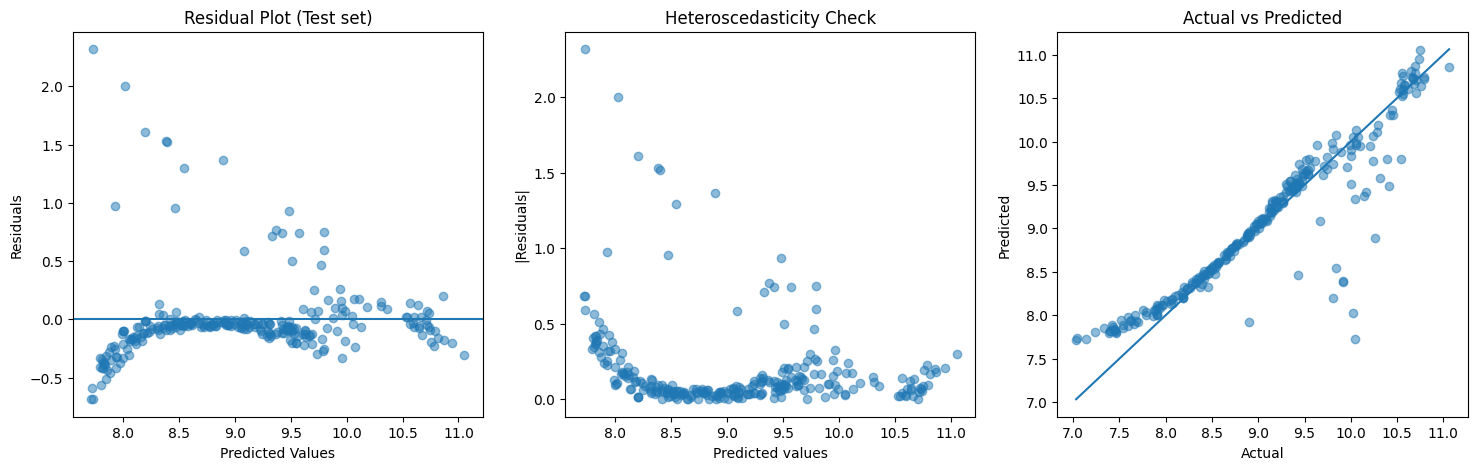

In [78]:
### Model Evaluation
scores = evaluate_model(pipe_post_lasso, X_train_post_lasso, X_test_post_lasso, y_train, y_test, log = True, name = 'Post-Lasso OLS')

### Add scores to results dataframe
results.loc['Post-Lasso OLS'] = scores

### Graph residuals
graph_residuals(pipe_post_lasso, X_test_post_lasso, y_test)

### 5.5. Ridge

We implement a Ridge model on the feature engineered set.

In [79]:
### Initialize pipeline
pipe_ridge = Pipeline([
     ('scaler', StandardScaler()),
    ('model', RidgeCV(cv=5, alphas=np.logspace(-3, 3, 100), scoring='neg_mean_squared_error'))
])

### Fit model on training data
pipe_ridge.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.",array([1.0000...00000000e+03])
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error ` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination ` (:math:`R^2`) otherwise.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds.- :term:`CV splitter`

We present the Ridge alpha coefficient and coefficients of the regression.

In [ ]:
### Print Ridge alpha hypermeter value
print(f'Ridge alpha: {pipe_ridge.named_steps["model"].alpha_:.4f}')
print('-'*40)

### Ridge coefficients
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": pipe_ridge.named_steps["model"].coef_
}).sort_values("coef", key=abs, ascending=False)

### Ridge intercept
intercept_df = pd.DataFrame({
    "feature": ["intercept"],
    "coef": [pipe_ridge.named_steps["model"].intercept_]
})

### Add everything in the same dataframe
full_df = pd.concat([intercept_df, coef_df], ignore_index=True)

### Print dataframe
full_df

Ridge alpha: 0.2656
----------------------------------------
             feature      coef
0          intercept  9.113322
1       smoker x bmi  0.777606
2                age  0.580697
3       smoker x age -0.558743
4             smoker  0.261164
5       obese_smoker  0.162359
6           children  0.124053
7   region_southwest -0.068253
8   region_southeast -0.054429
9                sex  0.042963
10  region_northwest -0.025618
11               bmi  0.010154


We calculate evaluation metrics, and plot the residuals.


RidgeCV
----------------------------------------
Train:
CV RMSE: 4949.7920
RMSE: 4942.35
MAE:  2454.78
R²:   0.8308

Test:
RMSE: 4624.86
MAE:  2254.72
R²:   0.8622


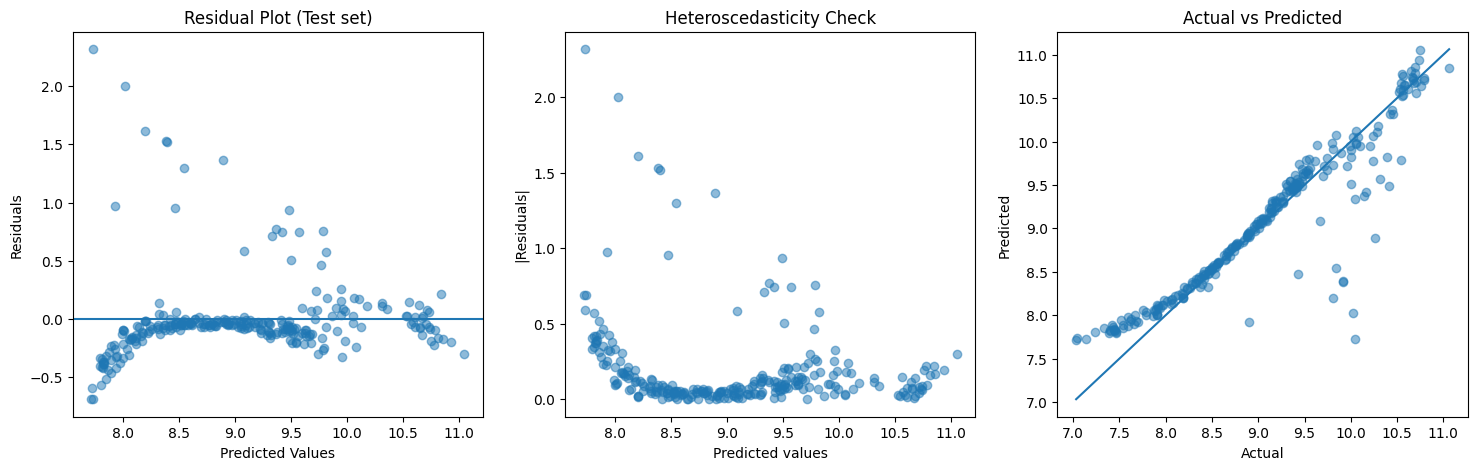

In [81]:
### Model Evaluation
scores = evaluate_model(pipe_ridge, X_train, X_test, y_train, y_test, log = True)

### Add scores to results dataframe
results.loc['Ridge'] = scores

### Graph residuals
graph_residuals(pipe_ridge, X_test, y_test)

### 5.6. Polynomial 

We implement a Polynomial regression model. Features are scaled before regressing with standar scaler. Grid Search is applied to determine optimal degree of polynomial features (between 1 and 3) and whether interaction terms are allowed.

In [82]:
### Initialize Pipeline
pipe_poly = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ("model", LinearRegression())
])

### Parameter grid for hyperparameter tuning
param_grid = {
    'poly__degree': [1, 2, 3],
    'poly__interaction_only': [False, True]
}

### Hyperparameter tuning with GridSearchCV
grid_poly = GridSearchCV(estimator=pipe_poly, param_grid=param_grid, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1, verbose = 1)

### Fit model on training data
grid_poly.fit(X_train_raw, y_train_raw)

### Choose best performing model
best_poly = grid_poly.best_estimator_

Fitting 5 folds for each of 6 candidates, totalling 30 fits


In [ ]:
### Polynomial features
poly_features = best_poly.named_steps["poly"].get_feature_names_out(X_train_raw.columns)

### Polynomial coefficients
coef_df = pd.DataFrame({
    "feature": poly_features,
    "value": best_poly.named_steps["model"].coef_
})

### Polynomial intercept
intercept_df = pd.DataFrame({
    "feature": ["intercept"],
    "value": [best_poly.named_steps["model"].intercept_]
})

### Add everything in the same dataframe
full_df = pd.concat([intercept_df, coef_df], ignore_index=True)

### Print dataframe
full_df

                              feature         value
0                           intercept  13346.089736
1                                 age  -1280.547948
2                                 sex    599.096203
3                                 bmi   2976.432347
4                            children   1414.364973
5                              smoker  -4195.040350
6                    region_northwest    -34.901210
7                    region_southeast    512.720710
8                    region_southwest     -4.780829
9                               age^2   4469.190623
10                            age sex   -389.427072
11                            age bmi    305.393763
12                       age children   -379.949892
13                         age smoker     62.191990
14               age region_northwest    448.124408
15               age region_southeast    937.365749
16               age region_southwest   1130.414756
17                              sex^2    599.096203
18          


Polynomial Regression
----------------------------------------
Train:
CV RMSE: 4887.2768
RMSE: 4778.19
MAE:  2892.15
R²:   0.8418

Test:
RMSE: 4551.13
MAE:  2729.50
R²:   0.8666


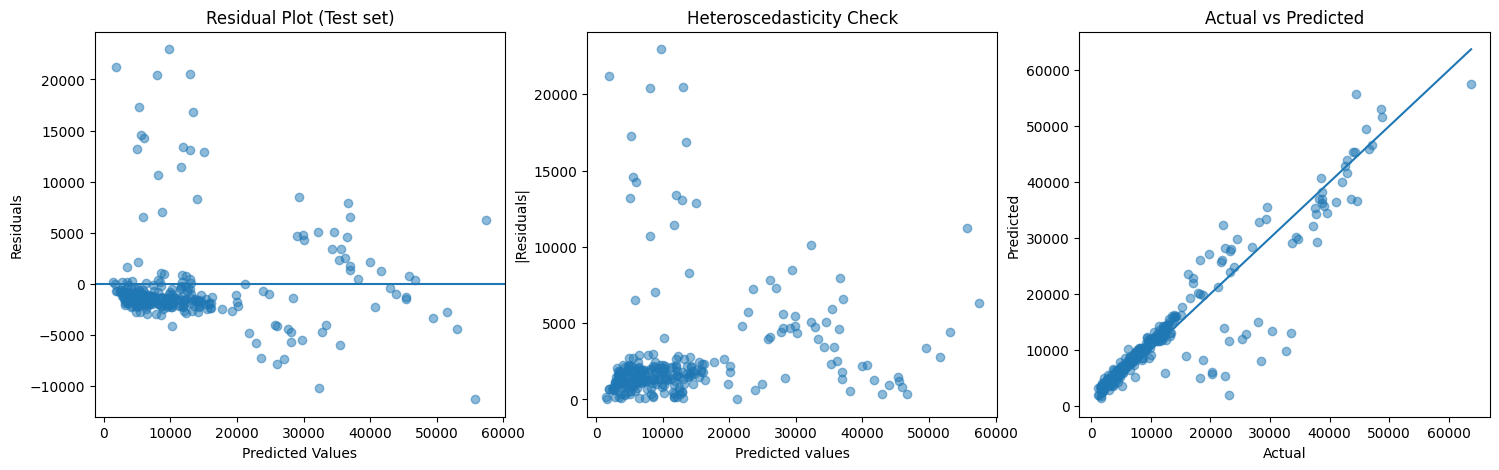

In [84]:
### Model Evaluation
scores = evaluate_model(best_poly, X_train_raw, X_test_raw, y_train_raw, y_test_raw, log = False, name = 'Polynomial Regression')

### Add scores to results dataframe
results.loc['Polynomial Regression'] = scores

### Graph residuals
graph_residuals(best_poly, X_test_raw, y_test_raw)

### 5.7. Random Forest

In [85]:
### Initialize Pipeline
pipe_rf = Pipeline([
    ('model', RandomForestRegressor(n_estimators=200, random_state=random_state))])

### Parameter grid for hyperparameter tuning
param_grid = {
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.5, 1.0]
}

### Hyperparameter tuning with GridSearchCV
grid_rf = GridSearchCV(estimator=pipe_rf, param_grid=param_grid, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1, verbose = 1)

### Fit model on training data
grid_rf.fit(X_train_raw, y_train_raw)

### Choose best performing model
best_rf = grid_rf.best_estimator_

Fitting 5 folds for each of 108 candidates, totalling 540 fits


In [ ]:
importance_df = pd.DataFrame({
    "feature": X_train_raw.columns,
    "importance": best_rf.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)

importance_df

            feature  importance
4            smoker    0.686387
2               bmi    0.182631
0               age    0.119939
3          children    0.008037
7  region_southwest    0.000832
6  region_southeast    0.000796
5  region_northwest    0.000756
1               sex    0.000622



RandomForestRegressor
----------------------------------------
Train:
CV RMSE: 4561.2244
RMSE: 4142.43
MAE:  2294.09
R²:   0.8811

Test:
RMSE: 4350.96
MAE:  2502.10
R²:   0.8781


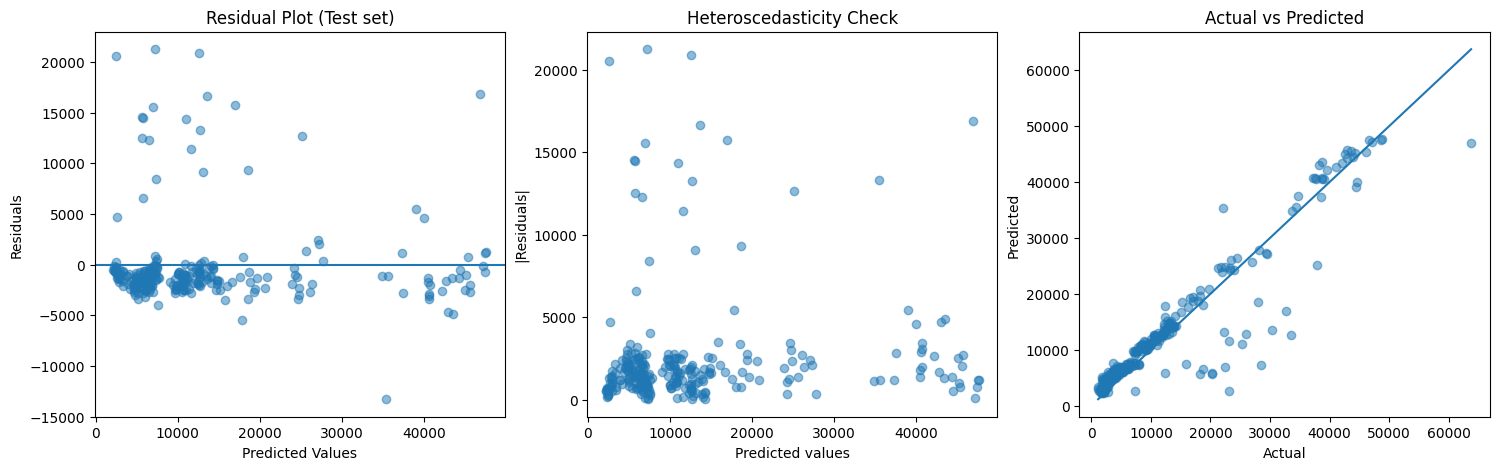

In [87]:
### Model Evaluation
scores = evaluate_model(best_rf, X_train_raw, X_test_raw, y_train_raw, y_test_raw, log = False, name = '')

### Add scores to results dataframe
results.loc['Random Forest'] = scores

### Graph residuals
graph_residuals(best_rf, X_test_raw, y_test_raw)

## 6. Final Evaluation

In [91]:
results

,CV_RMSE,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2
Model,,,,,,,
OLS,4962.673102,4949.643047,4631.220237,2460.556280,2256.679807,0.830262,0.861846
LASSO,4949.149386,4938.775727,4609.053567,2448.134882,2234.253605,0.831006,0.863166
Post-Lasso OLS,4962.673102,4949.643047,4631.220237,2460.556280,2256.679807,0.830262,0.861846
Ridge,4949.792024,4942.354453,4624.863221,2454.784996,2254.719818,0.830761,0.862225
Polynomial Regression,4887.276761,4778.187803,4551.132385,2892.149840,2729.500134,0.841817,0.866583
Random Forest,4561.224444,4142.431071,4350.955865,2294.090590,2502.095497,0.881111,0.878061
